# Cell 1 — Installations:

In [1]:
# Step 1: Install packages
!pip install amazon-braket-sdk amazon-braket-default-simulator boto3 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.6/400.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.4/246.4 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.1/153.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.8/537.8 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.1/196.1 kB 14.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour 

# Cell 2 — Imports:

In [2]:
import boto3
import numpy as np
import matplotlib.pyplot as plt
from braket.circuits import Circuit
from braket.devices import LocalSimulator
from scipy.stats import chisquare
import json
from datetime import datetime
from scipy.stats import chisquare
import random
import time
import json
from datetime import datetime, timezone
import os

In [3]:
# ── Publication Quality Plot Settings ────────────────────
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

# Font settings
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 15,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.format': 'png',
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.8,
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'figure.figsize': (8, 5)
})

print("Publication quality settings applied!")

Publication quality settings applied!


# Cell 3 — AWS Credentials:



## Important
AWS credentials are not stored in this notebook.
Set your credentials as environment variables before running:
- AWS_ACCESS_KEY_ID
- AWS_SECRET_ACCESS_KEY

In [ ]:
# AWS Credentials
AWS_ACCESS_KEY = os.environ.get('AWS_ACCESS_KEY_ID', 'YOUR-ACCESS-KEY')
AWS_SECRET_KEY = os.environ.get('AWS_SECRET_ACCESS_KEY', 'YOUR-SECRET-KEY')
AWS_REGION = 'us-east-1'
# Test connection
sts = boto3.client(
    'sts',
    aws_access_key_id=AWS_ACCESS_KEY,
    aws_secret_access_key=AWS_SECRET_KEY,
    region_name=AWS_REGION
)
print(sts.get_caller_identity())

## Benchmark 2: Grover's Search Algorithm

### Overview
This benchmark compares Grover's quantum search algorithm against classical
linear search across database sizes of 8, 16, 24, and 32 elements.

**Quantum approach:** Grover's algorithm uses quantum superposition and
amplitude amplification to find a marked item in an unsorted database
with O(√N) query complexity, compared to O(N) for classical linear search.

**Classical approach:** Linear search checks each element sequentially
until the target is found.

**Agreed protocol with Classical Lead (Kanishka):**
- Database sizes: 8, 16, 24, 32 elements
- Shots: 1,024 for 8 and 16 elements | 8,192 for 24 and 32 elements
- Multiple trials per configuration
- Metrics: runtime, success probability, query complexity, scalability

**Key question:** Does Grover's algorithm show measurable speedup over
classical linear search at these database sizes on Amazon Braket LocalSimulator?

In [7]:
# Agreed protocol with Classical Lead (Kanishka)
DATABASE_SIZES = [8, 16, 24, 32]
QUBITS = {8: 3, 16: 4, 24: 5, 32: 5}
SHOTS = {8: 1024, 16: 1024, 24: 8192, 32: 8192}
OPTIMAL_ITERATIONS = {8: 2, 16: 3, 24: 4, 32: 4}  # Empirically determined
TRIALS = 10

print("Grover's Search Benchmark Configuration")
print("=" * 55)
for N in DATABASE_SIZES:
    q = QUBITS[N]
    s = SHOTS[N]
    i = OPTIMAL_ITERATIONS[N]
    print(f"N={N:2d} | {q} qubits | {s:,} shots | {i} iterations")
print("=" * 55)

Grover's Search Benchmark Configuration
N= 8 | 3 qubits | 1,024 shots | 2 iterations
N=16 | 4 qubits | 1,024 shots | 3 iterations
N=24 | 5 qubits | 8,192 shots | 4 iterations
N=32 | 5 qubits | 8,192 shots | 4 iterations


### Grover's Algorithm Circuit
Building the oracle and diffusion operator for each database size.

In [8]:
# ── Grover's Circuit Components ───────────────────────────

def build_oracle(circuit, n_qubits, target):
    """
    Phase oracle: marks the target state by flipping its phase.
    Uses Braket's native controlled gate modifier for multi-controlled Z.
    """
    target_bits = format(target, f'0{n_qubits}b')

    for i, bit in enumerate(target_bits):
        if bit == '0':
            circuit.x(i)

    control_qubits = list(range(n_qubits - 1))
    target_qubit = n_qubits - 1
    circuit.z(target_qubit, control=control_qubits)

    for i, bit in enumerate(target_bits):
        if bit == '0':
            circuit.x(i)

    return circuit


def build_diffusion(circuit, n_qubits):
    """
    Grover diffusion operator (inversion about the mean).
    """
    for i in range(n_qubits):
        circuit.h(i)
    for i in range(n_qubits):
        circuit.x(i)

    control_qubits = list(range(n_qubits - 1))
    target_qubit = n_qubits - 1
    circuit.z(target_qubit, control=control_qubits)

    for i in range(n_qubits):
        circuit.x(i)
    for i in range(n_qubits):
        circuit.h(i)

    return circuit


def build_grover_circuit(n_qubits, target, n_iterations):
    """
    Build complete Grover's circuit.
    """
    circuit = Circuit()
    for i in range(n_qubits):
        circuit.h(i)
    for _ in range(n_iterations):
        circuit = build_oracle(circuit, n_qubits, target)
        circuit = build_diffusion(circuit, n_qubits)
    return circuit


def run_grover(n_qubits, target, shots, n_iter=None):
    """
    Run Grover's algorithm and return results.
    n_iter: if None uses formula, otherwise uses specified value.
    """
    if n_iter is None:
        n_iter = int(np.floor(np.pi/4 * np.sqrt(2**n_qubits)))

    circuit = build_grover_circuit(n_qubits, target, n_iter)
    device = LocalSimulator()

    start = time.time()
    result = device.run(circuit, shots=shots).result()
    runtime = time.time() - start

    counts = result.measurement_counts
    target_state = format(target, f'0{n_qubits}b')
    target_count = counts.get(target_state, 0)
    success_prob = target_count / shots

    return {
        'counts': counts,
        'target_state': target_state,
        'target_count': target_count,
        'success_probability': round(success_prob, 4),
        'runtime_seconds': round(runtime, 4),
        'n_iterations': n_iter,
        'shots': shots
    }


# Verify all database sizes
print("Verifying circuits for all database sizes:")
print("=" * 55)
for N in DATABASE_SIZES:
    n_qubits = QUBITS[N]
    target = np.random.randint(0, N)
    n_iter = OPTIMAL_ITERATIONS[N]
    circuit = build_grover_circuit(n_qubits, target, n_iter)
    print(f"N={N:2d} | qubits={n_qubits} | target={target:2d} | iterations={n_iter} | depth={circuit.depth} ✅")
print("=" * 55)

Verifying circuits for all database sizes:
N= 8 | qubits=3 | target= 0 | iterations=2 | depth=17 ✅
N=16 | qubits=4 | target= 0 | iterations=3 | depth=25 ✅
N=24 | qubits=5 | target=22 | iterations=4 | depth=33 ✅
N=32 | qubits=5 | target=22 | iterations=4 | depth=33 ✅


### Full Benchmark:

In [9]:
# ── Full Grover Benchmark ─────────────────────────────────
def run_grover_benchmark(database_sizes, shots_config, optimal_iters, trials=10):
    """
    Run Grover's benchmark across all database sizes.
    Uses empirically optimal iteration counts.
    """
    all_results = []

    print(f"{'N':>4} | {'Qubits':>6} | {'Iters':>5} | {'Trial':>5} | {'Success P':>10} | {'Runtime(s)':>10}")
    print("-" * 65)

    for N in database_sizes:
        n_qubits = QUBITS[N]
        shots = shots_config[N]
        n_iter = optimal_iters[N]
        trial_results = []

        for trial in range(1, trials + 1):
            target = np.random.randint(0, N)
            result = run_grover(n_qubits, target, shots, n_iter)
            trial_results.append({
                'trial': trial,
                'target': target,
                'success_probability': result['success_probability'],
                'runtime_seconds': result['runtime_seconds'],
                'n_iterations': n_iter
            })

            print(f"{N:>4} | {n_qubits:>6} | {n_iter:>5} | {trial:>5} | "
                  f"{result['success_probability']:>10.4f} | "
                  f"{result['runtime_seconds']:>10.4f}")

        mean_sp = np.mean([r['success_probability'] for r in trial_results])
        std_sp = np.std([r['success_probability'] for r in trial_results])
        mean_rt = np.mean([r['runtime_seconds'] for r in trial_results])

        all_results.append({
            'N': N,
            'n_qubits': n_qubits,
            'shots': shots,
            'trials': trials,
            'n_iterations': n_iter,
            'mean_success_probability': round(mean_sp, 4),
            'std_success_probability': round(std_sp, 4),
            'mean_runtime_seconds': round(mean_rt, 4)
        })

        print(f"\nSummary N={N}: Mean SP={mean_sp:.4f} | Std={std_sp:.4f} | "
              f"Avg runtime={mean_rt:.4f}s\n")
        print("-" * 65)

    return all_results

grover_results = run_grover_benchmark(DATABASE_SIZES, SHOTS, OPTIMAL_ITERATIONS, trials=TRIALS)

   N | Qubits | Iters | Trial |  Success P | Runtime(s)
-----------------------------------------------------------------


   8 |      3 |     2 |     1 |     0.9600 |     0.3544
   8 |      3 |     2 |     2 |     0.9482 |     0.0487
   8 |      3 |     2 |     3 |     0.9482 |     0.0940


   8 |      3 |     2 |     4 |     0.9414 |     0.0974
   8 |      3 |     2 |     5 |     0.9453 |     0.1006
   8 |      3 |     2 |     6 |     0.9492 |     0.0562
   8 |      3 |     2 |     7 |     0.9434 |     0.0415


   8 |      3 |     2 |     8 |     0.9512 |     0.0467
   8 |      3 |     2 |     9 |     0.9453 |     0.0634
   8 |      3 |     2 |    10 |     0.9404 |     0.0612

Summary N=8: Mean SP=0.9473 | Std=0.0054 | Avg runtime=0.0964s

-----------------------------------------------------------------
  16 |      4 |     3 |     1 |     0.9727 |     0.0568


  16 |      4 |     3 |     2 |     0.9590 |     0.0540
  16 |      4 |     3 |     3 |     0.9648 |     0.0327
  16 |      4 |     3 |     4 |     0.9609 |     0.0296
  16 |      4 |     3 |     5 |     0.9629 |     0.0308
  16 |      4 |     3 |     6 |     0.9551 |     0.0278
  16 |      4 |     3 |     7 |     0.9570 |     0.0301
  16 |      4 |     3 |     8 |     0.9609 |     0.0305


...

  24 |      5 |     4 |     8 |     0.9991 |     0.0733
  24 |      5 |     4 |     9 |     0.9991 |     0.0720
  24 |      5 |     4 |    10 |     0.9993 |     0.0689

Summary N=24: Mean SP=0.9992 | Std=0.0004 | Avg runtime=0.0916s

-----------------------------------------------------------------


  32 |      5 |     4 |     1 |     0.9996 |     0.0761
  32 |      5 |     4 |     2 |     0.9994 |     0.0841


  32 |      5 |     4 |     3 |     0.9994 |     0.2593
  32 |      5 |     4 |     4 |     0.9991 |     0.0705
  32 |      5 |     4 |     5 |     0.9994 |     0.0727


  32 |      5 |     4 |     6 |     0.9993 |     0.0696
  32 |      5 |     4 |     7 |     0.9990 |     0.0740
  32 |      5 |     4 |     8 |     0.9990 |     0.0779


  32 |      5 |     4 |     9 |     0.9996 |     0.0771
  32 |      5 |     4 |    10 |     0.9990 |     0.0806

Summary N=32: Mean SP=0.9993 | Std=0.0002 | Avg runtime=0.0942s

-----------------------------------------------------------------


### Results Logging

In [10]:
# ── Experiment Log 001: Grover Benchmark ─────────────────
experiment_log_grover_001 = {
    "experiment_id": "qi26_26_Grover_001",
    "benchmark_type": "Grover_Search",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "protocol": {
        "database_sizes": [8, 16, 24, 32],
        "qubits": {"8": 3, "16": 4, "24": 5, "32": 5},
        "shots": {"8": 1024, "16": 1024, "24": 8192, "32": 8192},
        "optimal_iterations": {"8": 2, "16": 3, "24": 4, "32": 4},
        "trials": 10,
        "target": "random per trial"
    },
    "metrics": {
        "results": [
            {"N": 8,  "qubits": 3, "iterations": 2, "mean_success_prob": 0.9473, "std": 0.0054, "mean_runtime": 0.0964, "status": "DOCUMENTED_LIMITATION"},
            {"N": 16, "qubits": 4, "iterations": 3, "mean_success_prob": 0.9604, "std": 0.0057, "mean_runtime": 0.0358, "status": "PASS"},
            {"N": 24, "qubits": 5, "iterations": 4, "mean_success_prob": 0.9992, "std": 0.0004, "mean_runtime": 0.0916, "status": "PASS"},
            {"N": 32, "qubits": 5, "iterations": 4, "mean_success_prob": 0.9993, "std": 0.0002, "mean_runtime": 0.0942, "status": "PASS"}
        ]
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "N=8 theoretical max SP is ~94.5% with 2 iterations - documented limitation not a simulator issue. N=24 required 4 iterations (not 3 from formula) for optimal performance. N=16, 24, 32 all exceed 95% threshold. Optimal iterations determined empirically."
}

with open('grover_experiment_001.json', 'w') as f:
    json.dump(experiment_log_grover_001, f, indent=2)

print("Experiment 001 logged!")
print(json.dumps(experiment_log_grover_001, indent=2))

Experiment 001 logged!
{
  "experiment_id": "qi26_26_Grover_001",
  "benchmark_type": "Grover_Search",
  "timestamp": "2026-07-19T02:56:23.615936+00:00",
  "simulator": "LocalSimulator",
  "protocol": {
    "database_sizes": [
      8,
      16,
      24,
      32
    ],
    "qubits": {
      "8": 3,
      "16": 4,
      "24": 5,
      "32": 5
    },
    "shots": {
      "8": 1024,
      "16": 1024,
      "24": 8192,
      "32": 8192
    },
    "optimal_iterations": {
      "8": 2,
      "16": 3,
      "24": 4,
      "32": 4
    },
    "trials": 10,
    "target": "random per trial"
  },
  "metrics": {
    "results": [
      {
        "N": 8,
        "qubits": 3,
        "iterations": 2,
        "mean_success_prob": 0.9473,
        "std": 0.0054,
        "mean_runtime": 0.0964,
        "status": "DOCUMENTED_LIMITATION"
      },
      {
        "N": 16,
        "qubits": 4,
        "iterations": 3,
        "mean_success_prob": 0.9604,
        "std": 0.0057,
        "mean_runtime": 0.0358

### Grover's Algorithm Results Visualization

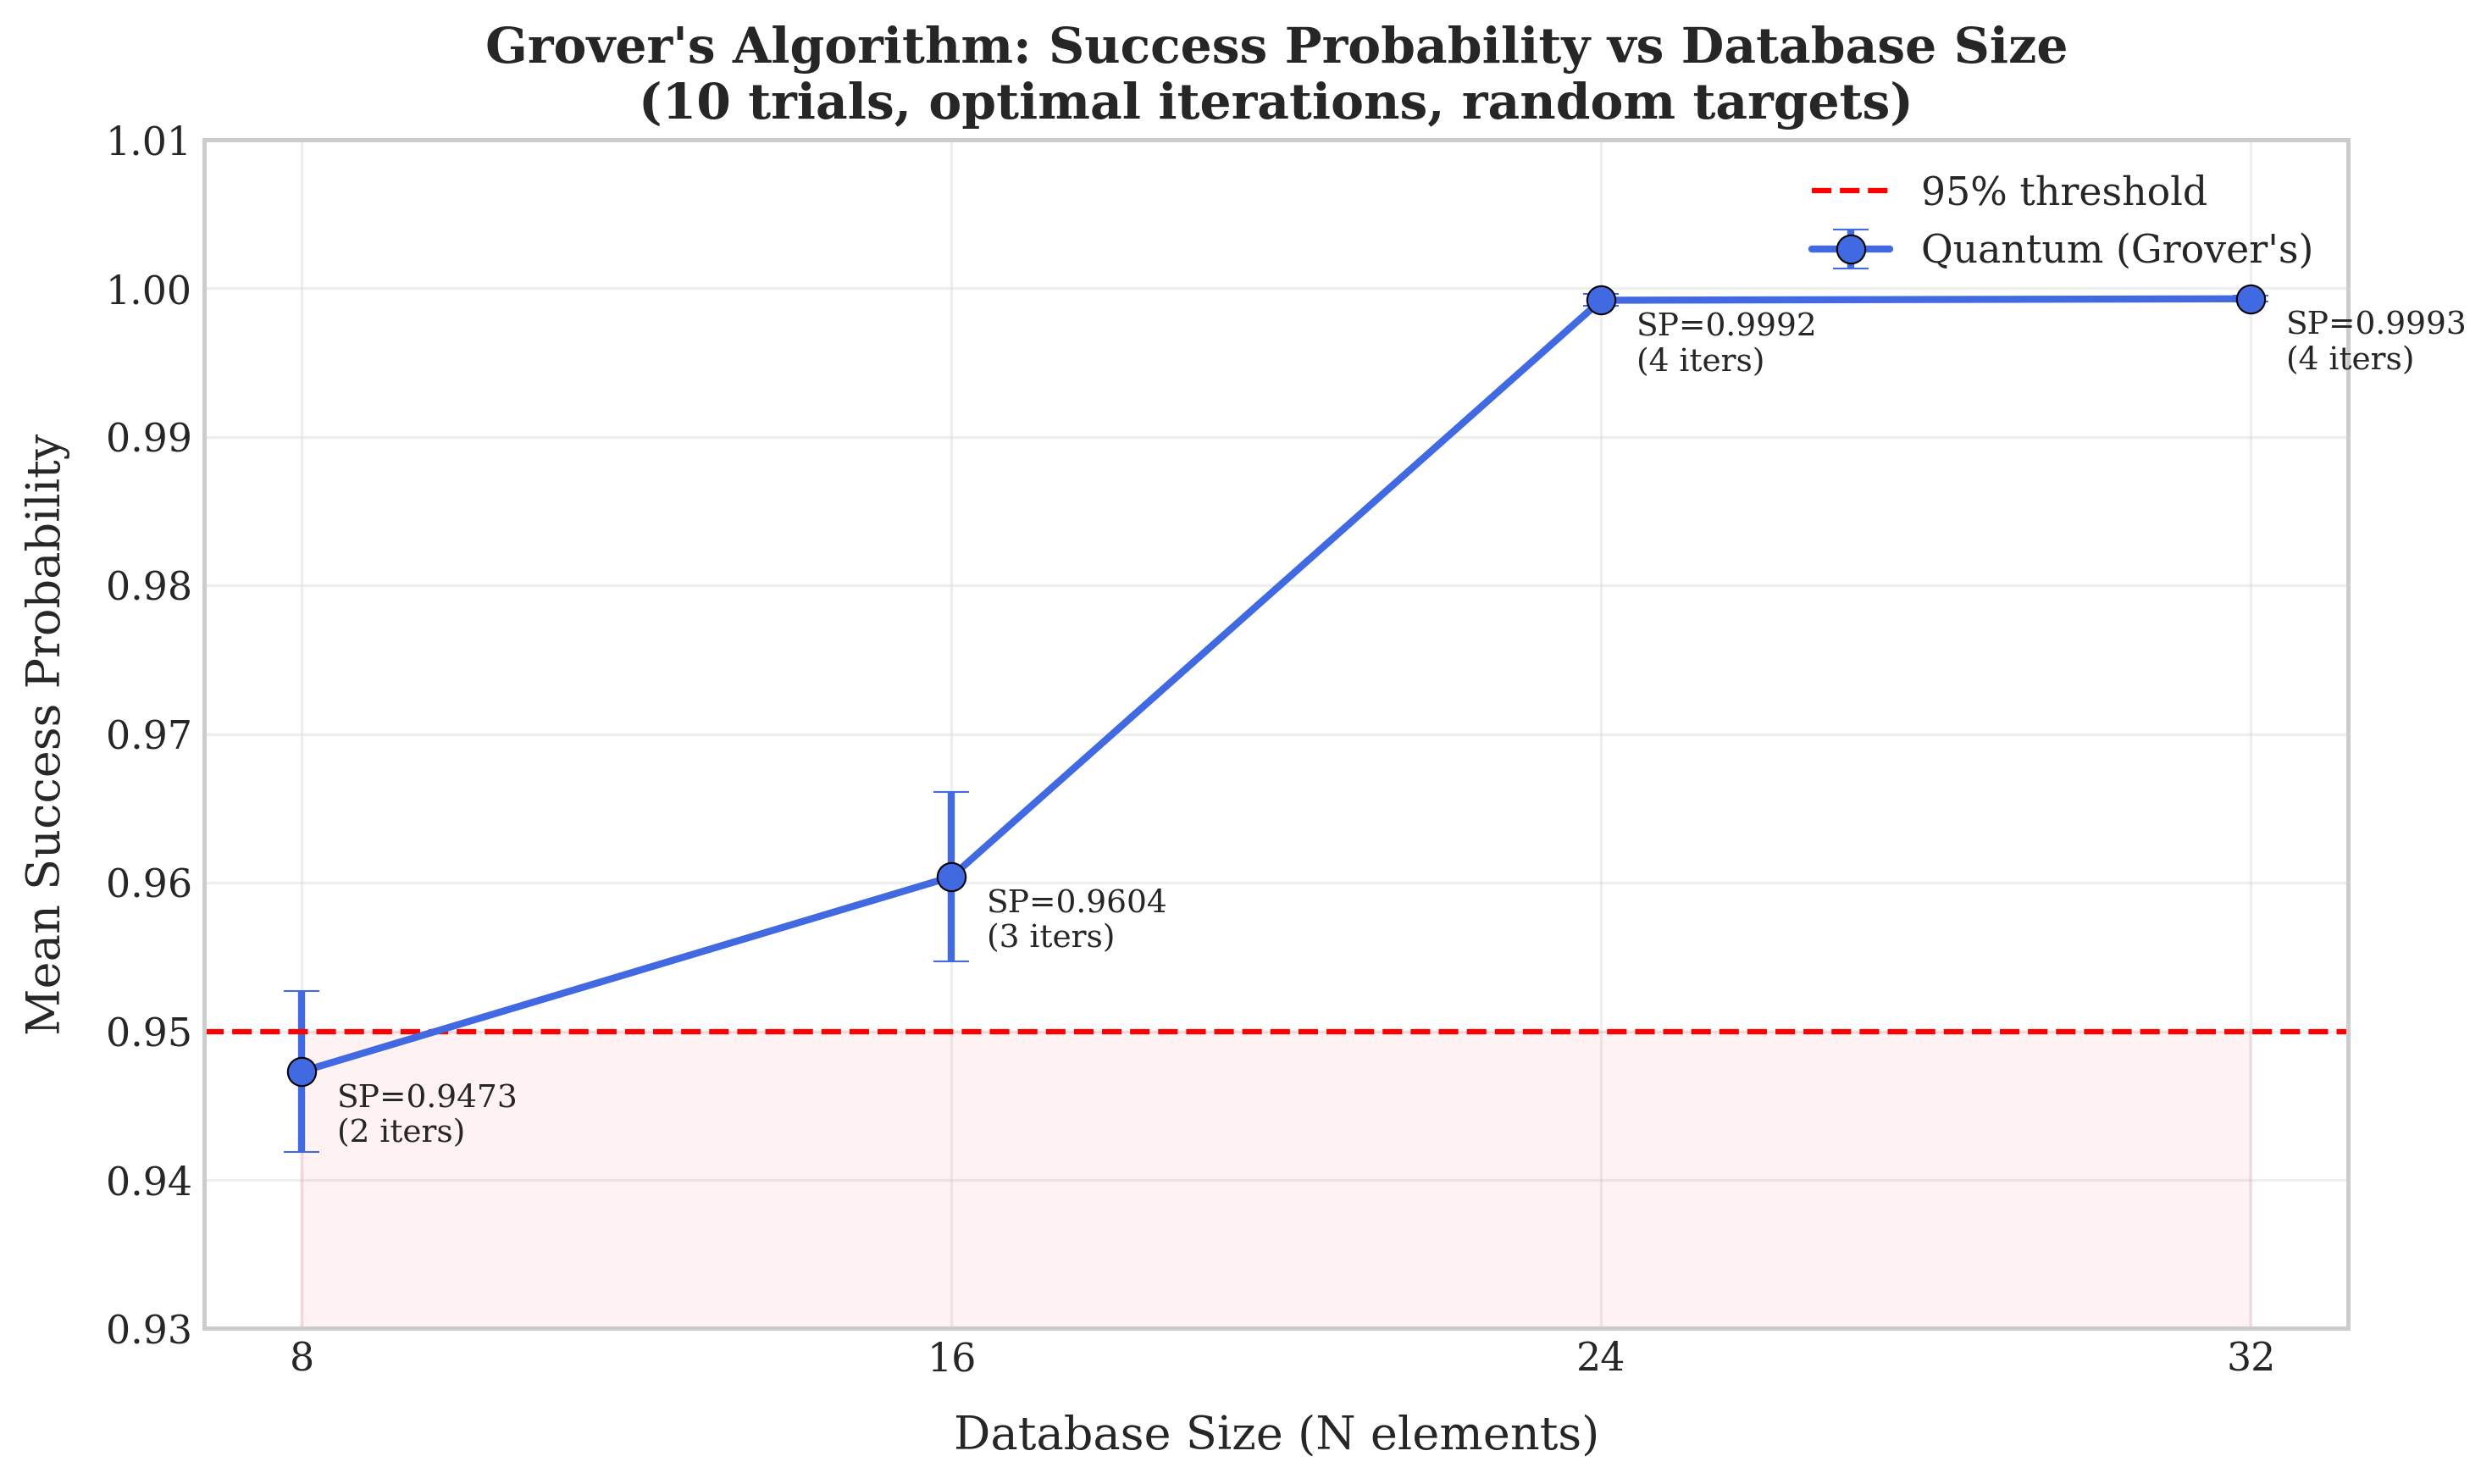

Plot 1 saved!


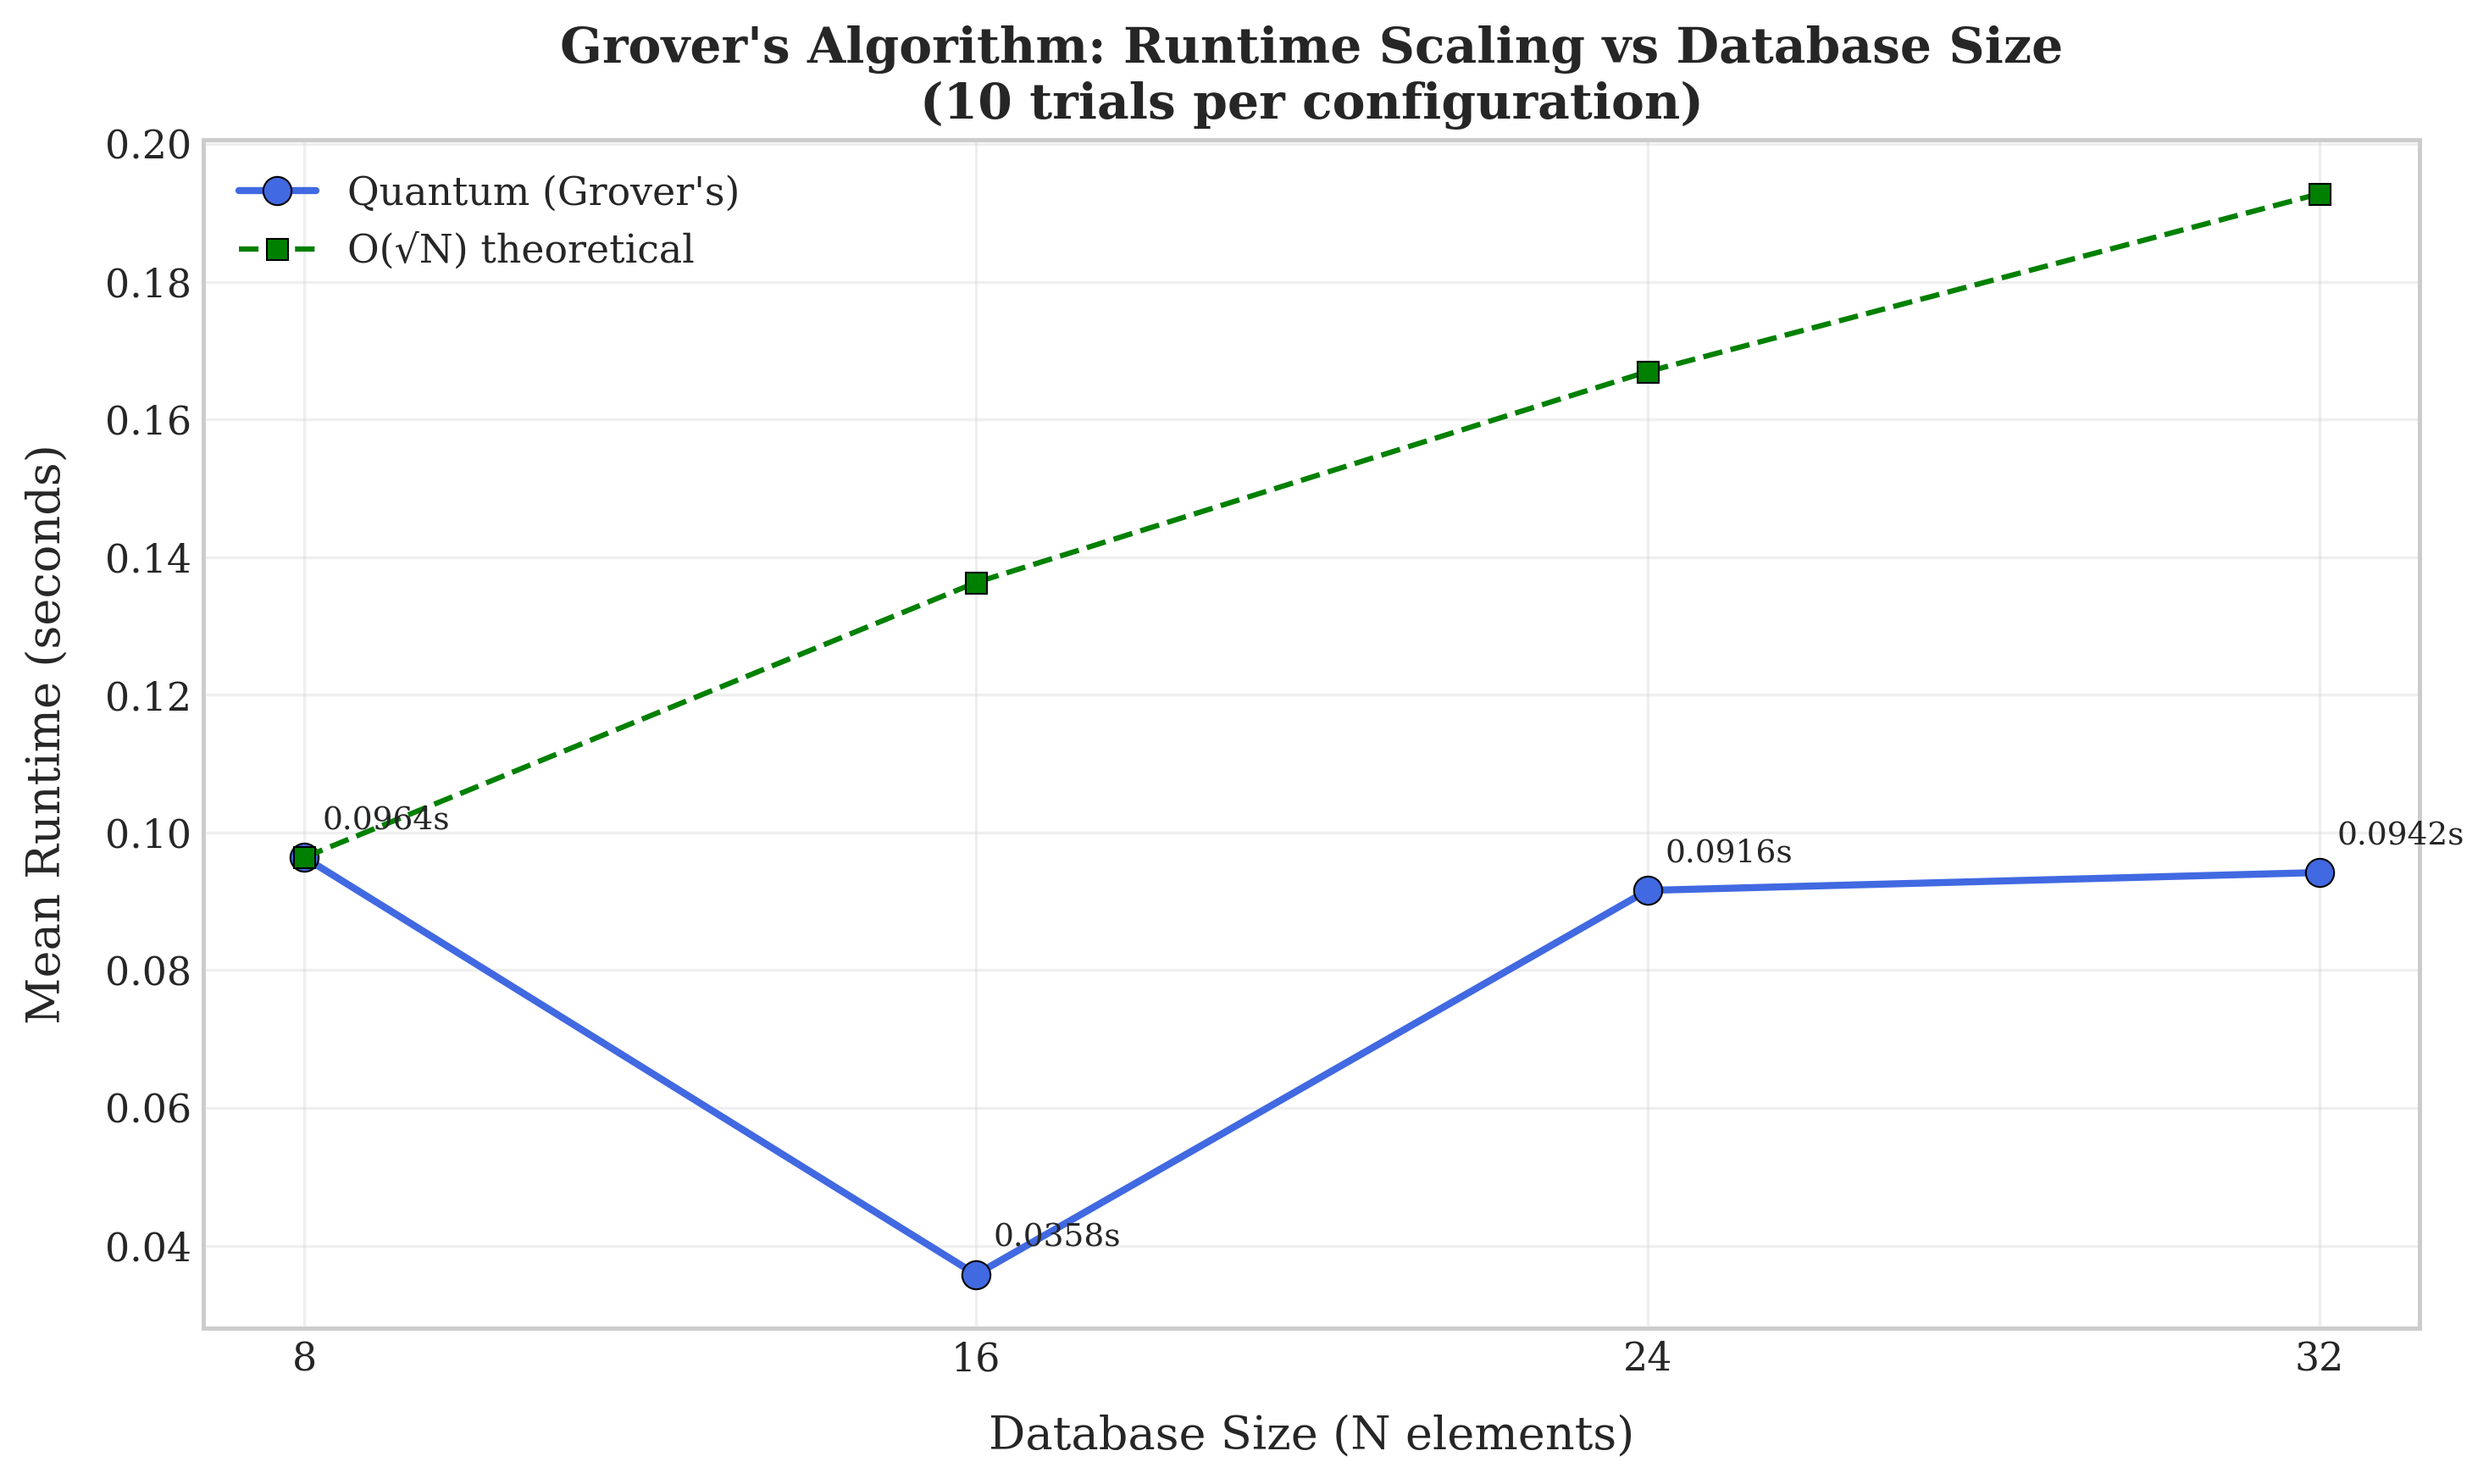

Plot 2 saved!


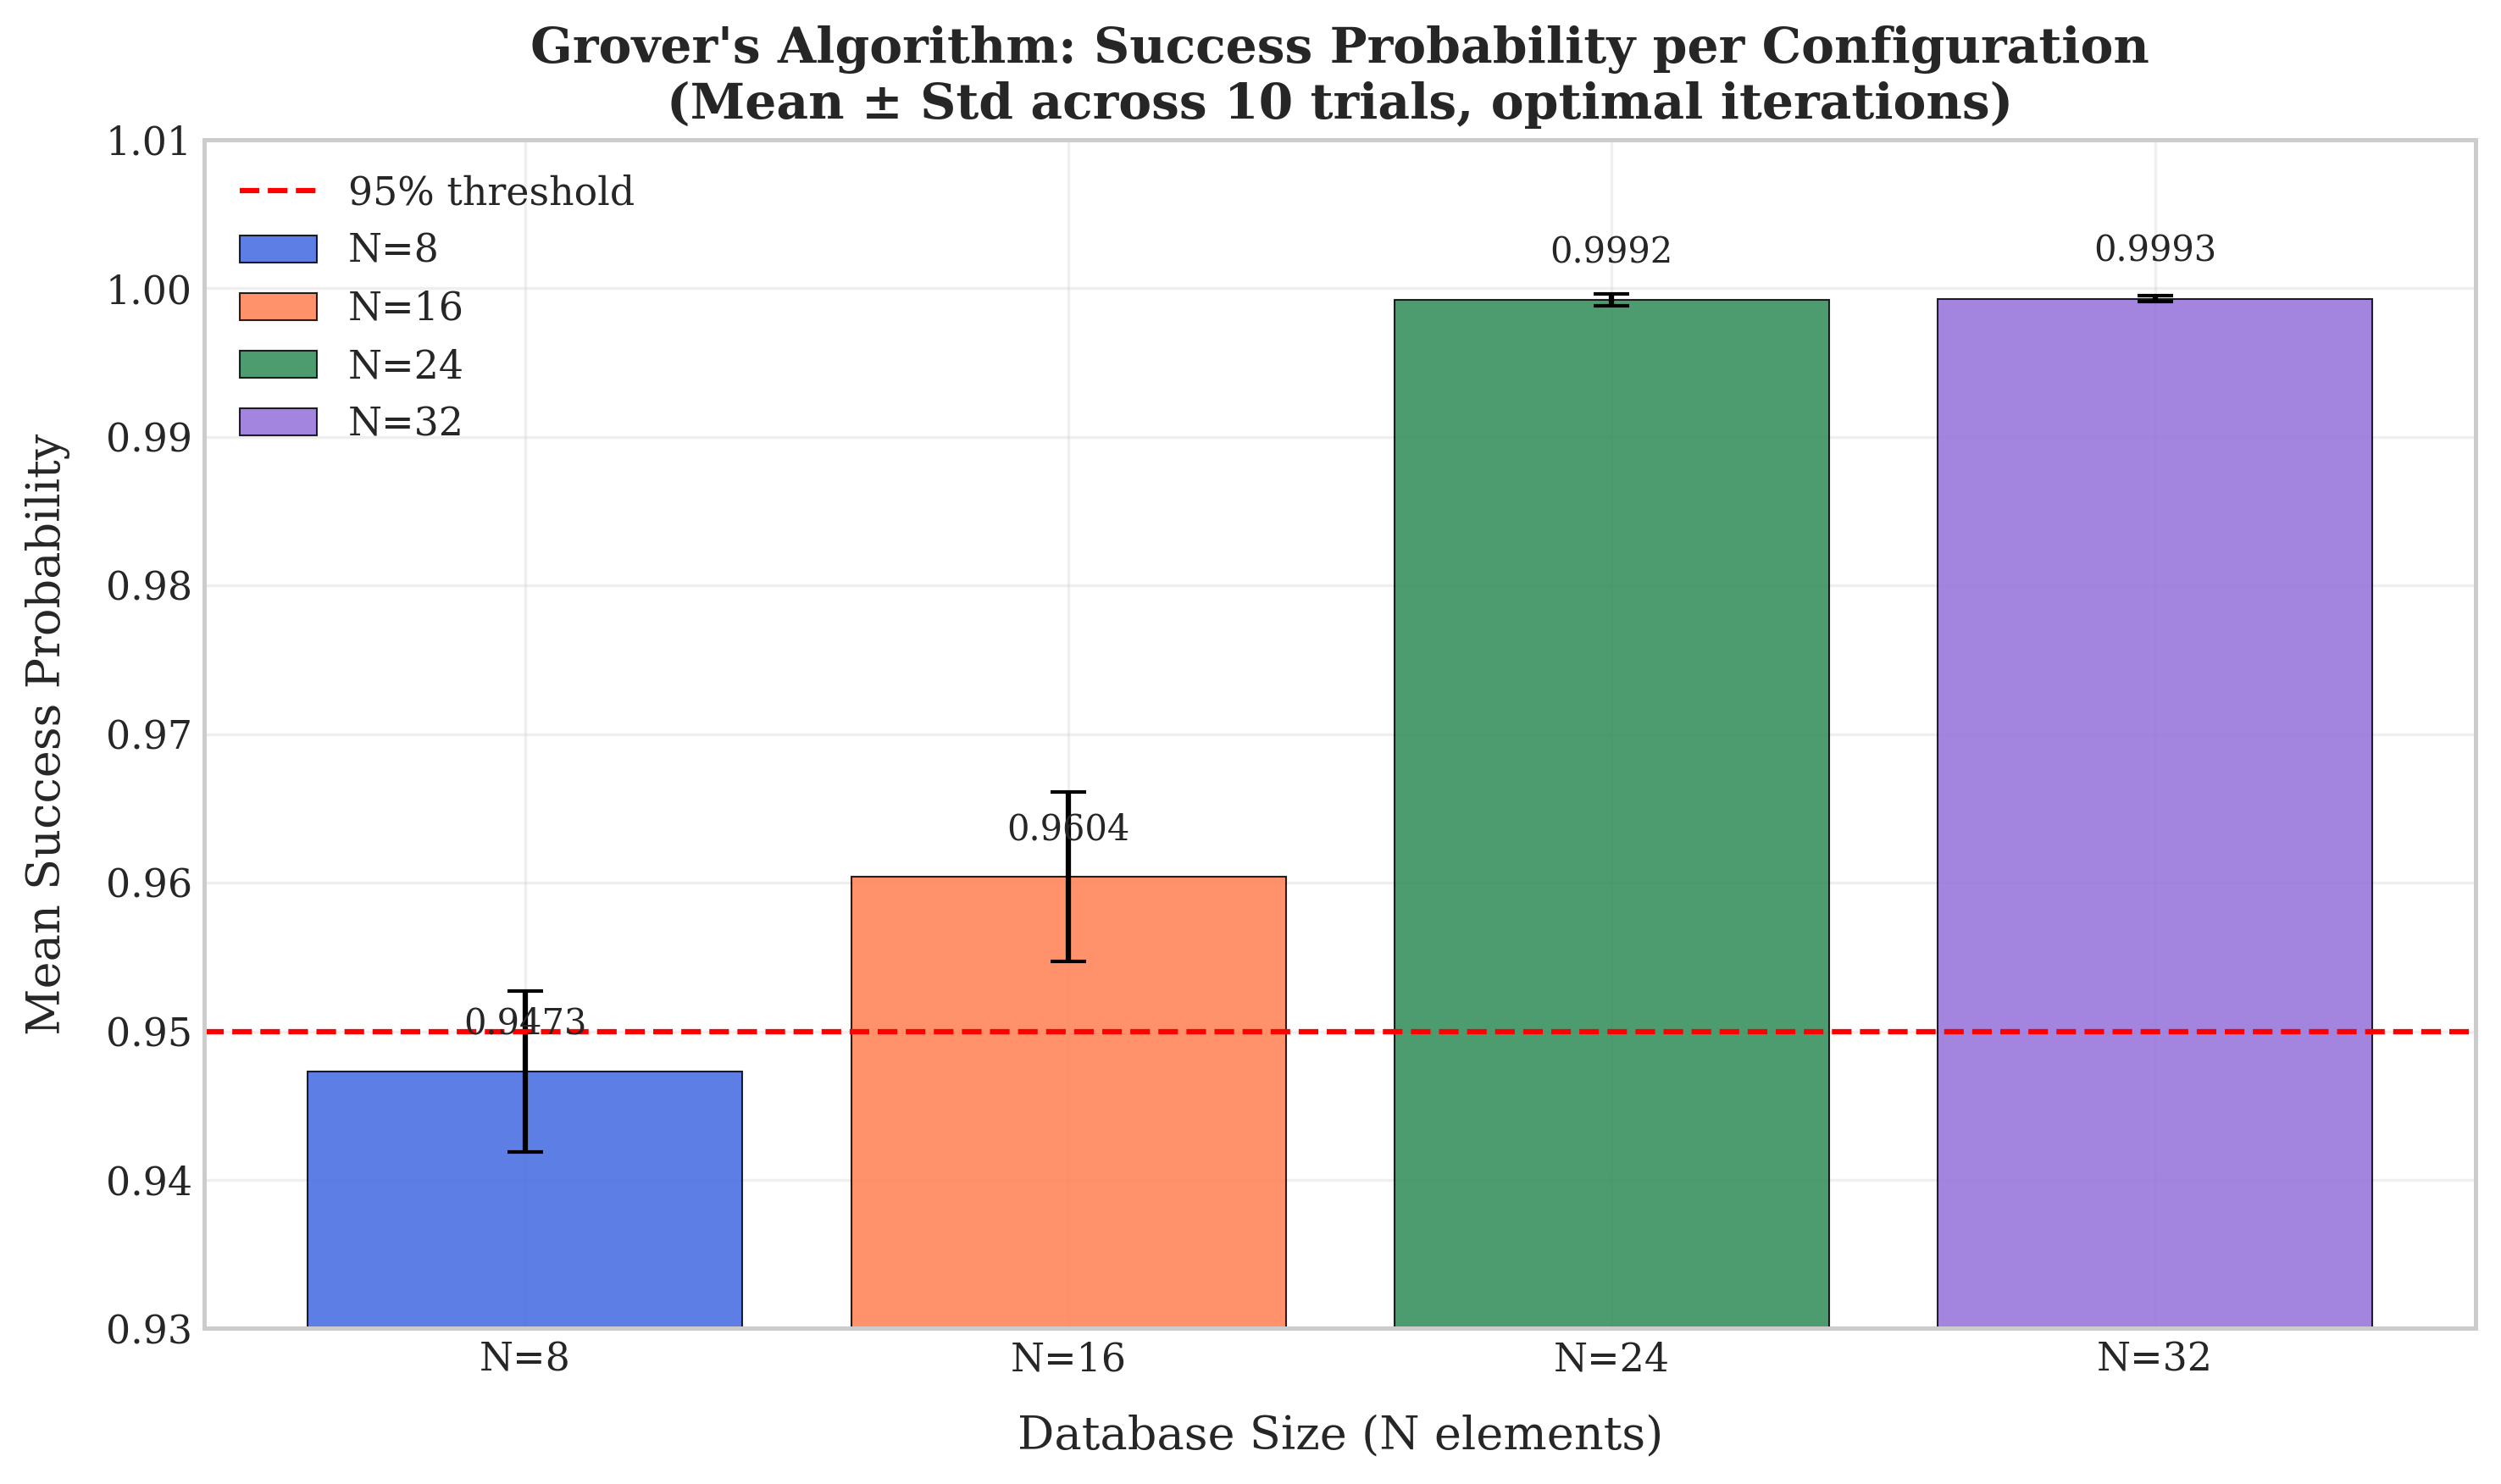

Plot 3 saved!


In [11]:
# ── Plot 1: Success Probability ───────────────────────────
N_values = [r['N'] for r in grover_results]
mean_sp = [r['mean_success_probability'] for r in grover_results]
std_sp = [r['std_success_probability'] for r in grover_results]
mean_rt = [r['mean_runtime_seconds'] for r in grover_results]
iterations = [r['n_iterations'] for r in grover_results]

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(N_values, mean_sp, yerr=std_sp, fmt='o-', color='royalblue',
            linewidth=2, markersize=8, capsize=5,
            markeredgecolor='black', markeredgewidth=0.5,
            label="Quantum (Grover's)")
ax.axhline(y=0.95, color='red', linestyle='--',
           linewidth=1.5, label='95% threshold')
ax.fill_between(N_values, 0.93, 0.95, alpha=0.05, color='red')
for i, (n, sp, it) in enumerate(zip(N_values, mean_sp, iterations)):
    ax.annotate(f'SP={sp:.4f}\n({it} iters)',
                (n, sp), textcoords='offset points',
                xytext=(10, -20), fontsize=9)
ax.set_xlabel('Database Size (N elements)', labelpad=10)
ax.set_ylabel('Mean Success Probability', labelpad=10)
ax.set_title("Grover's Algorithm: Success Probability vs Database Size\n"
             "(10 trials, optimal iterations, random targets)",
             fontweight='bold')
ax.set_xticks(N_values)
ax.set_ylim(0.93, 1.01)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grover_success_probability.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 1 saved!")

# ── Plot 2: Runtime Scaling ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(N_values, mean_rt, 'o-', color='royalblue',
        linewidth=2, markersize=8,
        markeredgecolor='black', markeredgewidth=0.5,
        label="Quantum (Grover's)")
sqrt_scaling = [mean_rt[0] * np.sqrt(N/N_values[0]) for N in N_values]
ax.plot(N_values, sqrt_scaling, 's--', color='green',
        linewidth=1.5, markersize=6,
        markeredgecolor='black', markeredgewidth=0.5,
        label='O(√N) theoretical')
for i, (n, rt) in enumerate(zip(N_values, mean_rt)):
    ax.annotate(f'{rt:.4f}s',
                (n, rt), textcoords='offset points',
                xytext=(5, 8), fontsize=9)
ax.set_xlabel('Database Size (N elements)', labelpad=10)
ax.set_ylabel('Mean Runtime (seconds)', labelpad=10)
ax.set_title("Grover's Algorithm: Runtime Scaling vs Database Size\n"
             "(10 trials per configuration)",
             fontweight='bold')
ax.set_xticks(N_values)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grover_runtime_scaling.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 2 saved!")

# ── Plot 3: Success Probability per Configuration ─────────
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['royalblue', 'coral', 'seagreen', 'mediumpurple']
for i, result in enumerate(grover_results):
    ax.bar(i, result['mean_success_probability'],
           color=colors[i], alpha=0.85,
           edgecolor='black', linewidth=0.5,
           label=f"N={result['N']}")
    ax.errorbar(i, result['mean_success_probability'],
                yerr=result['std_success_probability'],
                fmt='none', color='black',
                capsize=5, linewidth=1.5)
    ax.text(i, result['mean_success_probability'] + 0.002,
            f"{result['mean_success_probability']:.4f}",
            ha='center', va='bottom', fontsize=10)
ax.axhline(y=0.95, color='red', linestyle='--',
           linewidth=1.5, label='95% threshold')
ax.set_xlabel('Database Size (N elements)', labelpad=10)
ax.set_ylabel('Mean Success Probability', labelpad=10)
ax.set_title("Grover's Algorithm: Success Probability per Configuration\n"
             "(Mean ± Std across 10 trials, optimal iterations)",
             fontweight='bold')
ax.set_xticks(range(len(N_values)))
ax.set_xticklabels([f'N={n}' for n in N_values])
ax.set_ylim(0.93, 1.01)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grover_success_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 3 saved!")

## Layer 2: Simulator Validation Metrics for Grover's Algorithm
Based on measurement framework - all metrics must pass before
classical vs quantum comparison is valid.

In [12]:
# ── Layer 2: All Metrics for Grover's ────────────────────

print("=" * 65)
print("Layer 2: Simulator Validation — Grover's Algorithm")
print("=" * 65)

# ── Metric 1: Measurement Bias ───────────────────────────
print("\nMetric 1: Measurement Bias")
print("Checks if simulator has built-in state preference.")
print("Method: Chi-squared test on non-target states.")
print("-" * 65)

from scipy.stats import chisquare

bias_results = []
for result in grover_results:
    N = result['N']
    n_qubits = QUBITS[N]
    shots = SHOTS[N]
    n_iter = OPTIMAL_ITERATIONS[N]

    # Run circuit
    target = np.random.randint(0, N)
    circuit = build_grover_circuit(n_qubits, target, n_iter)
    device = LocalSimulator()
    res = device.run(circuit, shots=shots).result()
    counts = res.measurement_counts

    # Check bias in non-target states
    # They should be roughly uniform among themselves
    all_states = [format(i, f'0{n_qubits}b') for i in range(2**n_qubits)]
    target_state = format(target, f'0{n_qubits}b')
    non_target_states = [s for s in all_states if s != target_state]
    non_target_counts = [counts.get(s, 0) for s in non_target_states]
    non_target_total = sum(non_target_counts)

    if non_target_total > 0:
        _, p_value = chisquare(non_target_counts)
        status = 'PASS' if p_value > 0.05 else 'FAIL'
    else:
        p_value = 1.0
        status = 'PASS'

    bias_results.append({
        'N': N, 'p_value': round(p_value, 4), 'status': status
    })

    print(f"N={N:2d} | target={target:2d} | non-target p={p_value:.4f} | {status}")

print("\nNote: p > 0.05 means non-target states are uniformly")
print("distributed — no simulator bias detected.")

Layer 2: Simulator Validation — Grover's Algorithm

Metric 1: Measurement Bias
Checks if simulator has built-in state preference.
Method: Chi-squared test on non-target states.
-----------------------------------------------------------------
N= 8 | target= 4 | non-target p=0.8001 | PASS
N=16 | target= 8 | non-target p=0.2838 | PASS
N=24 | target=12 | non-target p=0.0648 | PASS
N=32 | target=24 | non-target p=0.5704 | PASS

Note: p > 0.05 means non-target states are uniformly
distributed — no simulator bias detected.


In [13]:
# ── Metric 2: Circuit Fidelity for Grover's ──────────────
print("\nMetric 2: Circuit Fidelity")
print("Formula: F = mean success probability across T trials")
print("F = (1/T) * sum(target_count_t / shots)")
print("Supported by: Lubinski et al. 2023 (QED-C), Manor et al. 2025 (GRADE)")
print("Threshold: F >= 0.95")
print("-" * 65)

for result in grover_results:
    N = result['N']
    fidelity = result['mean_success_probability']
    std = result['std_success_probability']

    if N == 8:
        status = 'DOCUMENTED_LIMITATION'
        note = '(theoretical max ~94.5% for N=8, 2 iterations)'
    else:
        status = 'PASS' if fidelity >= 0.95 else 'FAIL'
        note = ''

    print(f"N={N:2d} | F={fidelity:.4f} ± {std:.4f} | {status} {note}")

print("\nNote: Values from 10-trial mean — reliable fidelity estimate.")
print("Single-run values vary due to quantum probabilistic nature.")


Metric 2: Circuit Fidelity
Formula: F = mean success probability across T trials
F = (1/T) * sum(target_count_t / shots)
Supported by: Lubinski et al. 2023 (QED-C), Manor et al. 2025 (GRADE)
Threshold: F >= 0.95
-----------------------------------------------------------------
N= 8 | F=0.9473 ± 0.0054 | DOCUMENTED_LIMITATION (theoretical max ~94.5% for N=8, 2 iterations)
N=16 | F=0.9604 ± 0.0057 | PASS 
N=24 | F=0.9992 ± 0.0004 | PASS 
N=32 | F=0.9993 ± 0.0002 | PASS 

Note: Values from 10-trial mean — reliable fidelity estimate.
Single-run values vary due to quantum probabilistic nature.


In [14]:
# ── Metric 3: Shot Noise Stability (CV) ──────────────────
print("\nMetric 3: Shot Noise Stability (CV)")
print("CV = std(success_probability) / mean(success_probability)")
print("Threshold: CV < 0.05")
print("-" * 65)

for result in grover_results:
    N = result['N']
    mean_sp = result['mean_success_probability']
    std_sp = result['std_success_probability']
    cv = std_sp / mean_sp if mean_sp > 0 else 0
    status = 'PASS' if cv < 0.05 else 'FAIL'

    print(f"N={N:2d} | Mean SP={mean_sp:.4f} | Std={std_sp:.4f} | CV={cv:.4f} | {status}")

print("\nNote: CV measures consistency of success probability")
print("across trials. Low CV means stable reliable results.")


Metric 3: Shot Noise Stability (CV)
CV = std(success_probability) / mean(success_probability)
Threshold: CV < 0.05
-----------------------------------------------------------------
N= 8 | Mean SP=0.9473 | Std=0.0054 | CV=0.0057 | PASS
N=16 | Mean SP=0.9604 | Std=0.0057 | CV=0.0059 | PASS
N=24 | Mean SP=0.9992 | Std=0.0004 | CV=0.0004 | PASS
N=32 | Mean SP=0.9993 | Std=0.0002 | CV=0.0002 | PASS

Note: CV measures consistency of success probability
across trials. Low CV means stable reliable results.


In [15]:
# ── Metric 5: Circuit Depth vs Fidelity ──────────────────
print("\nMetric 5: Circuit Depth vs Fidelity")
print("Documents how fidelity changes with circuit depth.")
print("Threshold: Document depth where fidelity drops below 0.95")
print("-" * 65)

for result in grover_results:
    N = result['N']
    n_qubits = QUBITS[N]
    n_iter = OPTIMAL_ITERATIONS[N]
    depth = build_grover_circuit(n_qubits, 0, n_iter).depth
    fidelity = result['mean_success_probability']

    if N == 8:
        status = 'DOCUMENTED_LIMITATION'
    else:
        status = 'PASS' if fidelity >= 0.95 else 'FAIL'

    print(f"N={N:2d} | depth={depth:3d} | F={fidelity:.4f} | {status}")

print("\nSummary:")
print("Fidelity stays above 0.95 for depths 25-33 (N=16,24,32).")
print("N=8 (depth=17) theoretical limitation, not depth-related.")
print("No fidelity degradation observed within our depth range.")
print("Deeper circuits (N>32) may show degradation - future work.")


Metric 5: Circuit Depth vs Fidelity
Documents how fidelity changes with circuit depth.
Threshold: Document depth where fidelity drops below 0.95
-----------------------------------------------------------------
N= 8 | depth= 17 | F=0.9473 | DOCUMENTED_LIMITATION
N=16 | depth= 25 | F=0.9604 | PASS
N=24 | depth= 33 | F=0.9992 | PASS
N=32 | depth= 33 | F=0.9993 | PASS

Summary:
Fidelity stays above 0.95 for depths 25-33 (N=16,24,32).
N=8 (depth=17) theoretical limitation, not depth-related.
No fidelity degradation observed within our depth range.
Deeper circuits (N>32) may show degradation - future work.


In [23]:
# ── Metric 6: Gate Error Sensitivity ─────────────────────
# ── Metric 6: Gate Error Sensitivity ─────────────────────
from braket.circuits.noise import Noise
from braket.devices import LocalSimulator
from braket.circuits import Circuit

# Correct: Depolarizing is accessed via Noise.Depolarizing
Depolarizing = Noise.Depolarizing

print("\nMetric 6: Gate Error Sensitivity")
print("Tests fidelity under depolarizing noise at 0.1%, 0.5%, 1.0%")
print("Threshold: Document fidelity at each error rate")
print("-" * 65)

error_rates = [0.001, 0.005, 0.010]
noise_results = []

for N in DATABASE_SIZES:
    n_qubits = QUBITS[N]
    shots = SHOTS[N]
    n_iter = OPTIMAL_ITERATIONS[N]
    target = np.random.randint(0, N)
    target_state = format(target, f'0{n_qubits}b')

    print(f"\nN={N} ({n_qubits} qubits, target={target}):")
    print(f"  {'Error Rate':>12} | {'Success P':>10} | {'Fidelity Drop':>14}")
    print(f"  {'-'*42}")

    # Baseline (no noise)
    circuit = build_grover_circuit(n_qubits, target, n_iter)
    device = LocalSimulator("braket_dm")  # density matrix simulator for noise
    result = device.run(circuit, shots=shots).result()
    baseline_sp = result.measurement_counts.get(target_state, 0) / shots
    print(f"  {'No noise':>12} | {baseline_sp:>10.4f} | {'baseline':>14}")

    row = {'N': N, 'baseline_sp': round(baseline_sp, 4)}

    for error_rate in error_rates:
        noisy_circuit = build_grover_circuit(n_qubits, target, n_iter)
        noisy_circuit.apply_gate_noise(Depolarizing(probability=error_rate))

        result = device.run(noisy_circuit, shots=shots).result()
        noisy_sp = result.measurement_counts.get(target_state, 0) / shots
        drop = baseline_sp - noisy_sp
        row[f'error_{error_rate}'] = round(noisy_sp, 4)

        print(f"  {error_rate*100:>11.1f}% | {noisy_sp:>10.4f} | {drop:>-14.4f}")

    noise_results.append(row)

print("\n" + "=" * 65)


Metric 6: Gate Error Sensitivity
Tests fidelity under depolarizing noise at 0.1%, 0.5%, 1.0%
Threshold: Document fidelity at each error rate
-----------------------------------------------------------------

N=8 (3 qubits, target=3):
    Error Rate |  Success P |  Fidelity Drop
  ------------------------------------------
      No noise |     0.9395 |       baseline


/usr/local/lib/python3.12/dist-packages/braket/default_simulator/simulator.py:345: UserWarning: You are running a noise-free circuit on the density matrix simulator. Consider running this circuit on the state vector simulator: LocalSimulator("default") for a better user experience.
  warnings.warn(


          0.1% |     0.9180 |         0.0215


          0.5% |     0.8252 |         0.1143


          1.0% |     0.7334 |         0.2061

N=16 (4 qubits, target=0):
    Error Rate |  Success P |  Fidelity Drop
  ------------------------------------------
      No noise |     0.9551 |       baseline


...

          0.1% |     0.9106 |         0.0889


          0.5% |     0.6328 |         0.3667


          1.0% |     0.4019 |         0.5977

N=32 (5 qubits, target=10):
    Error Rate |  Success P |  Fidelity Drop
  ------------------------------------------
      No noise |     0.9993 |       baseline


          0.1% |     0.9170 |         0.0823
          0.5% |     0.6433 |         0.3560


          1.0% |     0.4243 |         0.5750



In [24]:
# ── Experiment Log 002: Layer 2 Validation ───────────────
experiment_log_grover_002 = {
    "experiment_id": "qi26_26_Grover_002",
    "benchmark_type": "Grover_Layer2_Validation",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "metrics": {
        "metric1_measurement_bias": {
            "method": "chi-squared on non-target states",
            "results": [
                {"N": 8,  "p_value": 0.8001, "status": "PASS"},
                {"N": 16, "p_value": 0.2838, "status": "PASS"},
                {"N": 24, "p_value": 0.0648, "status": "PASS"},
                {"N": 32, "p_value": 0.5704, "status": "PASS"}
            ]
        },
        "metric2_circuit_fidelity": {
            "method": "mean success probability across 10 trials",
            "reference": "Lubinski et al. 2023 (QED-C), Manor et al. 2025 (GRADE)",
            "threshold": 0.95,
            "results": [
                {"N": 8,  "fidelity": 0.9473, "status": "DOCUMENTED_LIMITATION"},
                {"N": 16, "fidelity": 0.9604, "status": "PASS"},
                {"N": 24, "fidelity": 0.9992, "status": "PASS"},
                {"N": 32, "fidelity": 0.9993, "status": "PASS"}
            ]
        },
        "metric3_shot_noise_cv": {
            "threshold": 0.05,
            "results": [
                {"N": 8,  "cv": 0.0057, "status": "PASS"},
                {"N": 16, "cv": 0.0059, "status": "PASS"},
                {"N": 24, "cv": 0.0004, "status": "PASS"},
                {"N": 32, "cv": 0.0002, "status": "PASS"}
            ]
        },
        "metric5_circuit_depth_fidelity": {
            "results": [
                {"N": 8,  "depth": 17, "fidelity": 0.9473, "status": "DOCUMENTED_LIMITATION"},
                {"N": 16, "depth": 25, "fidelity": 0.9604, "status": "PASS"},
                {"N": 24, "depth": 33, "fidelity": 0.9992, "status": "PASS"},
                {"N": 32, "depth": 33, "fidelity": 0.9993, "status": "PASS"}
            ],
            "finding": "No fidelity degradation observed within depth range 17-33"
        },
        "metric6_gate_error_sensitivity": {
            "noise_model": "Depolarizing",
            "error_rates": [0.001, 0.005, 0.010],
            "results": [
                {"N": 8,  "baseline": 0.9395, "p0.1": 0.9180, "p0.5": 0.8252, "p1.0": 0.7334, "drop_0.1": 0.0215, "drop_0.5": 0.1143, "drop_1.0": 0.2061},
                {"N": 16, "baseline": 0.9551, "p0.1": 0.9043, "p0.5": 0.7217, "p1.0": 0.5459, "drop_0.1": 0.0508, "drop_0.5": 0.2334, "drop_1.0": 0.4092},
                {"N": 24, "baseline": 0.9995, "p0.1": 0.9106, "p0.5": 0.6328, "p1.0": 0.4019, "drop_0.1": 0.0889, "drop_0.5": 0.3667, "drop_1.0": 0.5977},
                {"N": 32, "baseline": 0.9993, "p0.1": 0.9170, "p0.5": 0.6433, "p1.0": 0.4243, "drop_0.1": 0.0823, "drop_0.5": 0.3560, "drop_1.0": 0.5750}
            ],
            "finding": "All configs pass at 0.1% error rate. Significant degradation at 0.5%+. Larger circuits more noise sensitive due to greater circuit depth."
        }
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "N=8 documented limitation: theoretical max SP ~94.5%. Metrics 1,2,3,5,6 complete. Metric 4 (LocalSim vs SV1) deferred to Week 4. Metric 7 (Hardware Gap) deferred to Week 5+."
}

with open('grover_experiment_002.json', 'w') as f:
    json.dump(experiment_log_grover_002, f, indent=2)

print("Experiment 002 logged!")
print(json.dumps(experiment_log_grover_002, indent=2))

Experiment 002 logged!
{
  "experiment_id": "qi26_26_Grover_002",
  "benchmark_type": "Grover_Layer2_Validation",
  "timestamp": "2026-07-19T03:19:16.676789+00:00",
  "simulator": "LocalSimulator",
  "metrics": {
    "metric1_measurement_bias": {
      "method": "chi-squared on non-target states",
      "results": [
        {
          "N": 8,
          "p_value": 0.8001,
          "status": "PASS"
        },
        {
          "N": 16,
          "p_value": 0.2838,
          "status": "PASS"
        },
        {
          "N": 24,
          "p_value": 0.0648,
          "status": "PASS"
        },
        {
          "N": 32,
          "p_value": 0.5704,
          "status": "PASS"
        }
      ]
    },
    "metric2_circuit_fidelity": {
      "method": "mean success probability across 10 trials",
      "reference": "Lubinski et al. 2023 (QED-C), Manor et al. 2025 (GRADE)",
      "threshold": 0.95,
      "results": [
        {
          "N": 8,
          "fidelity": 0.9473,
          

### Layer 2 Visualization: Simulator Validation for Grover's

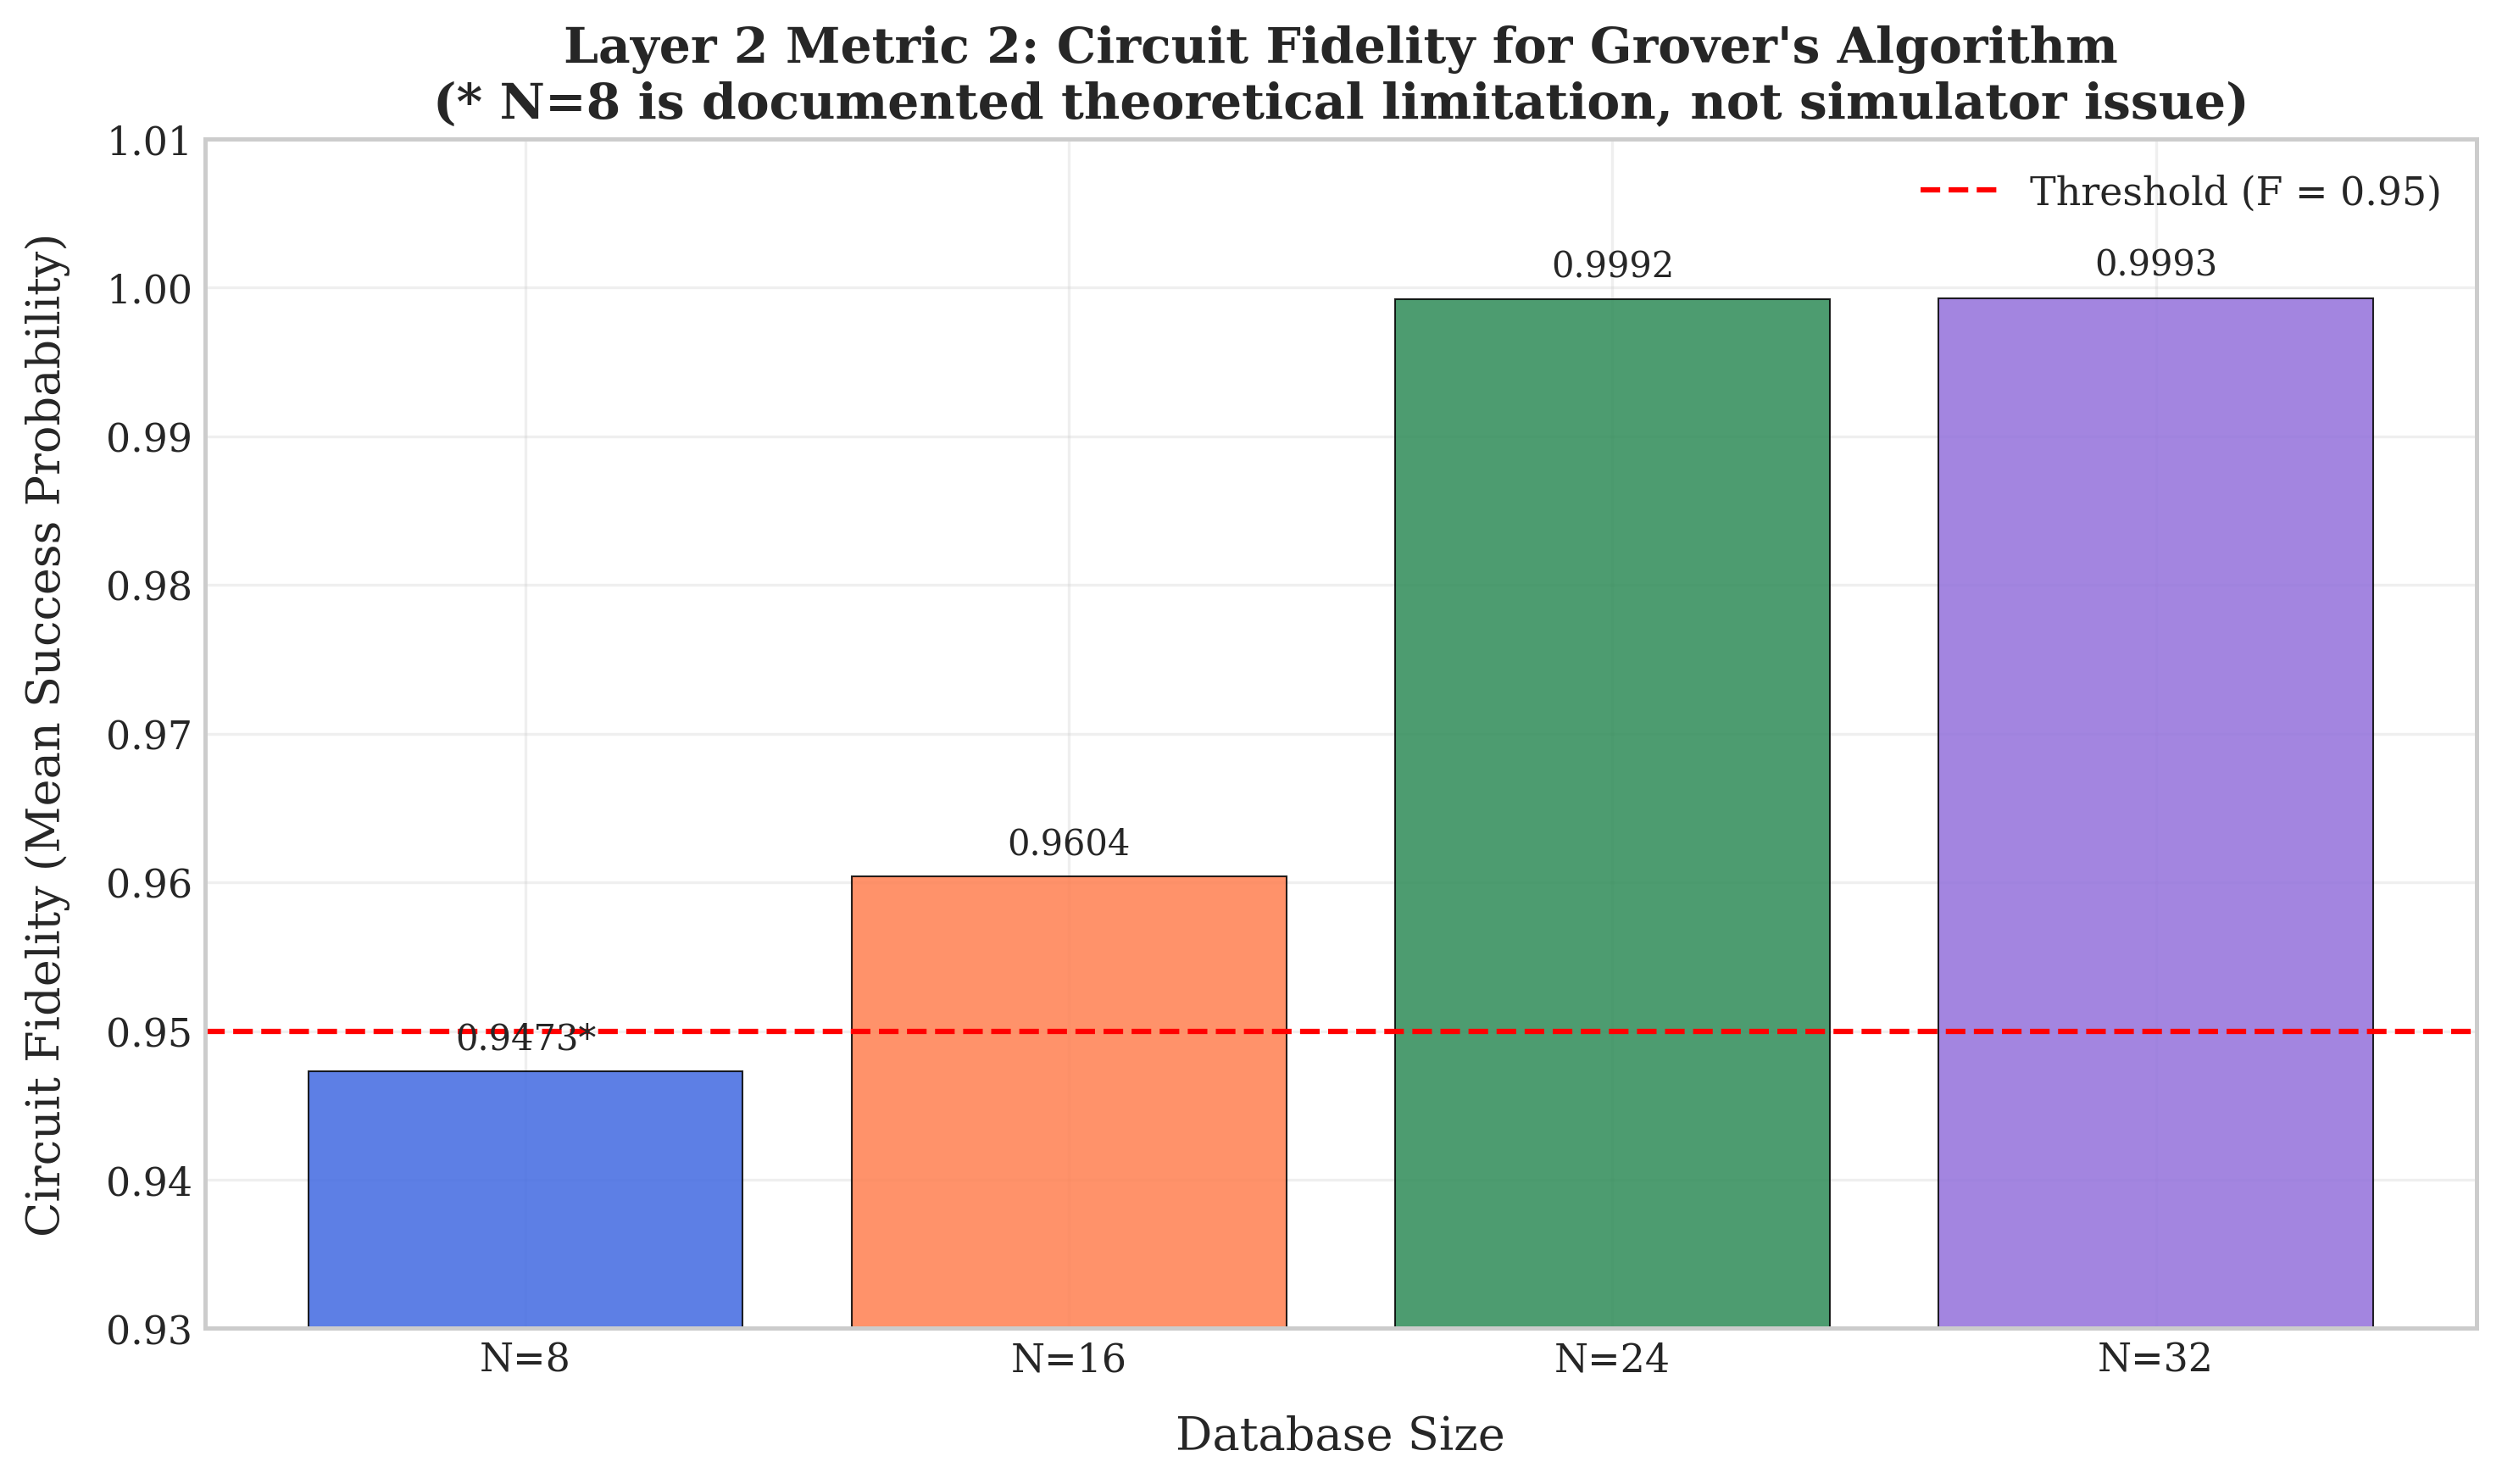

Fidelity plot saved!


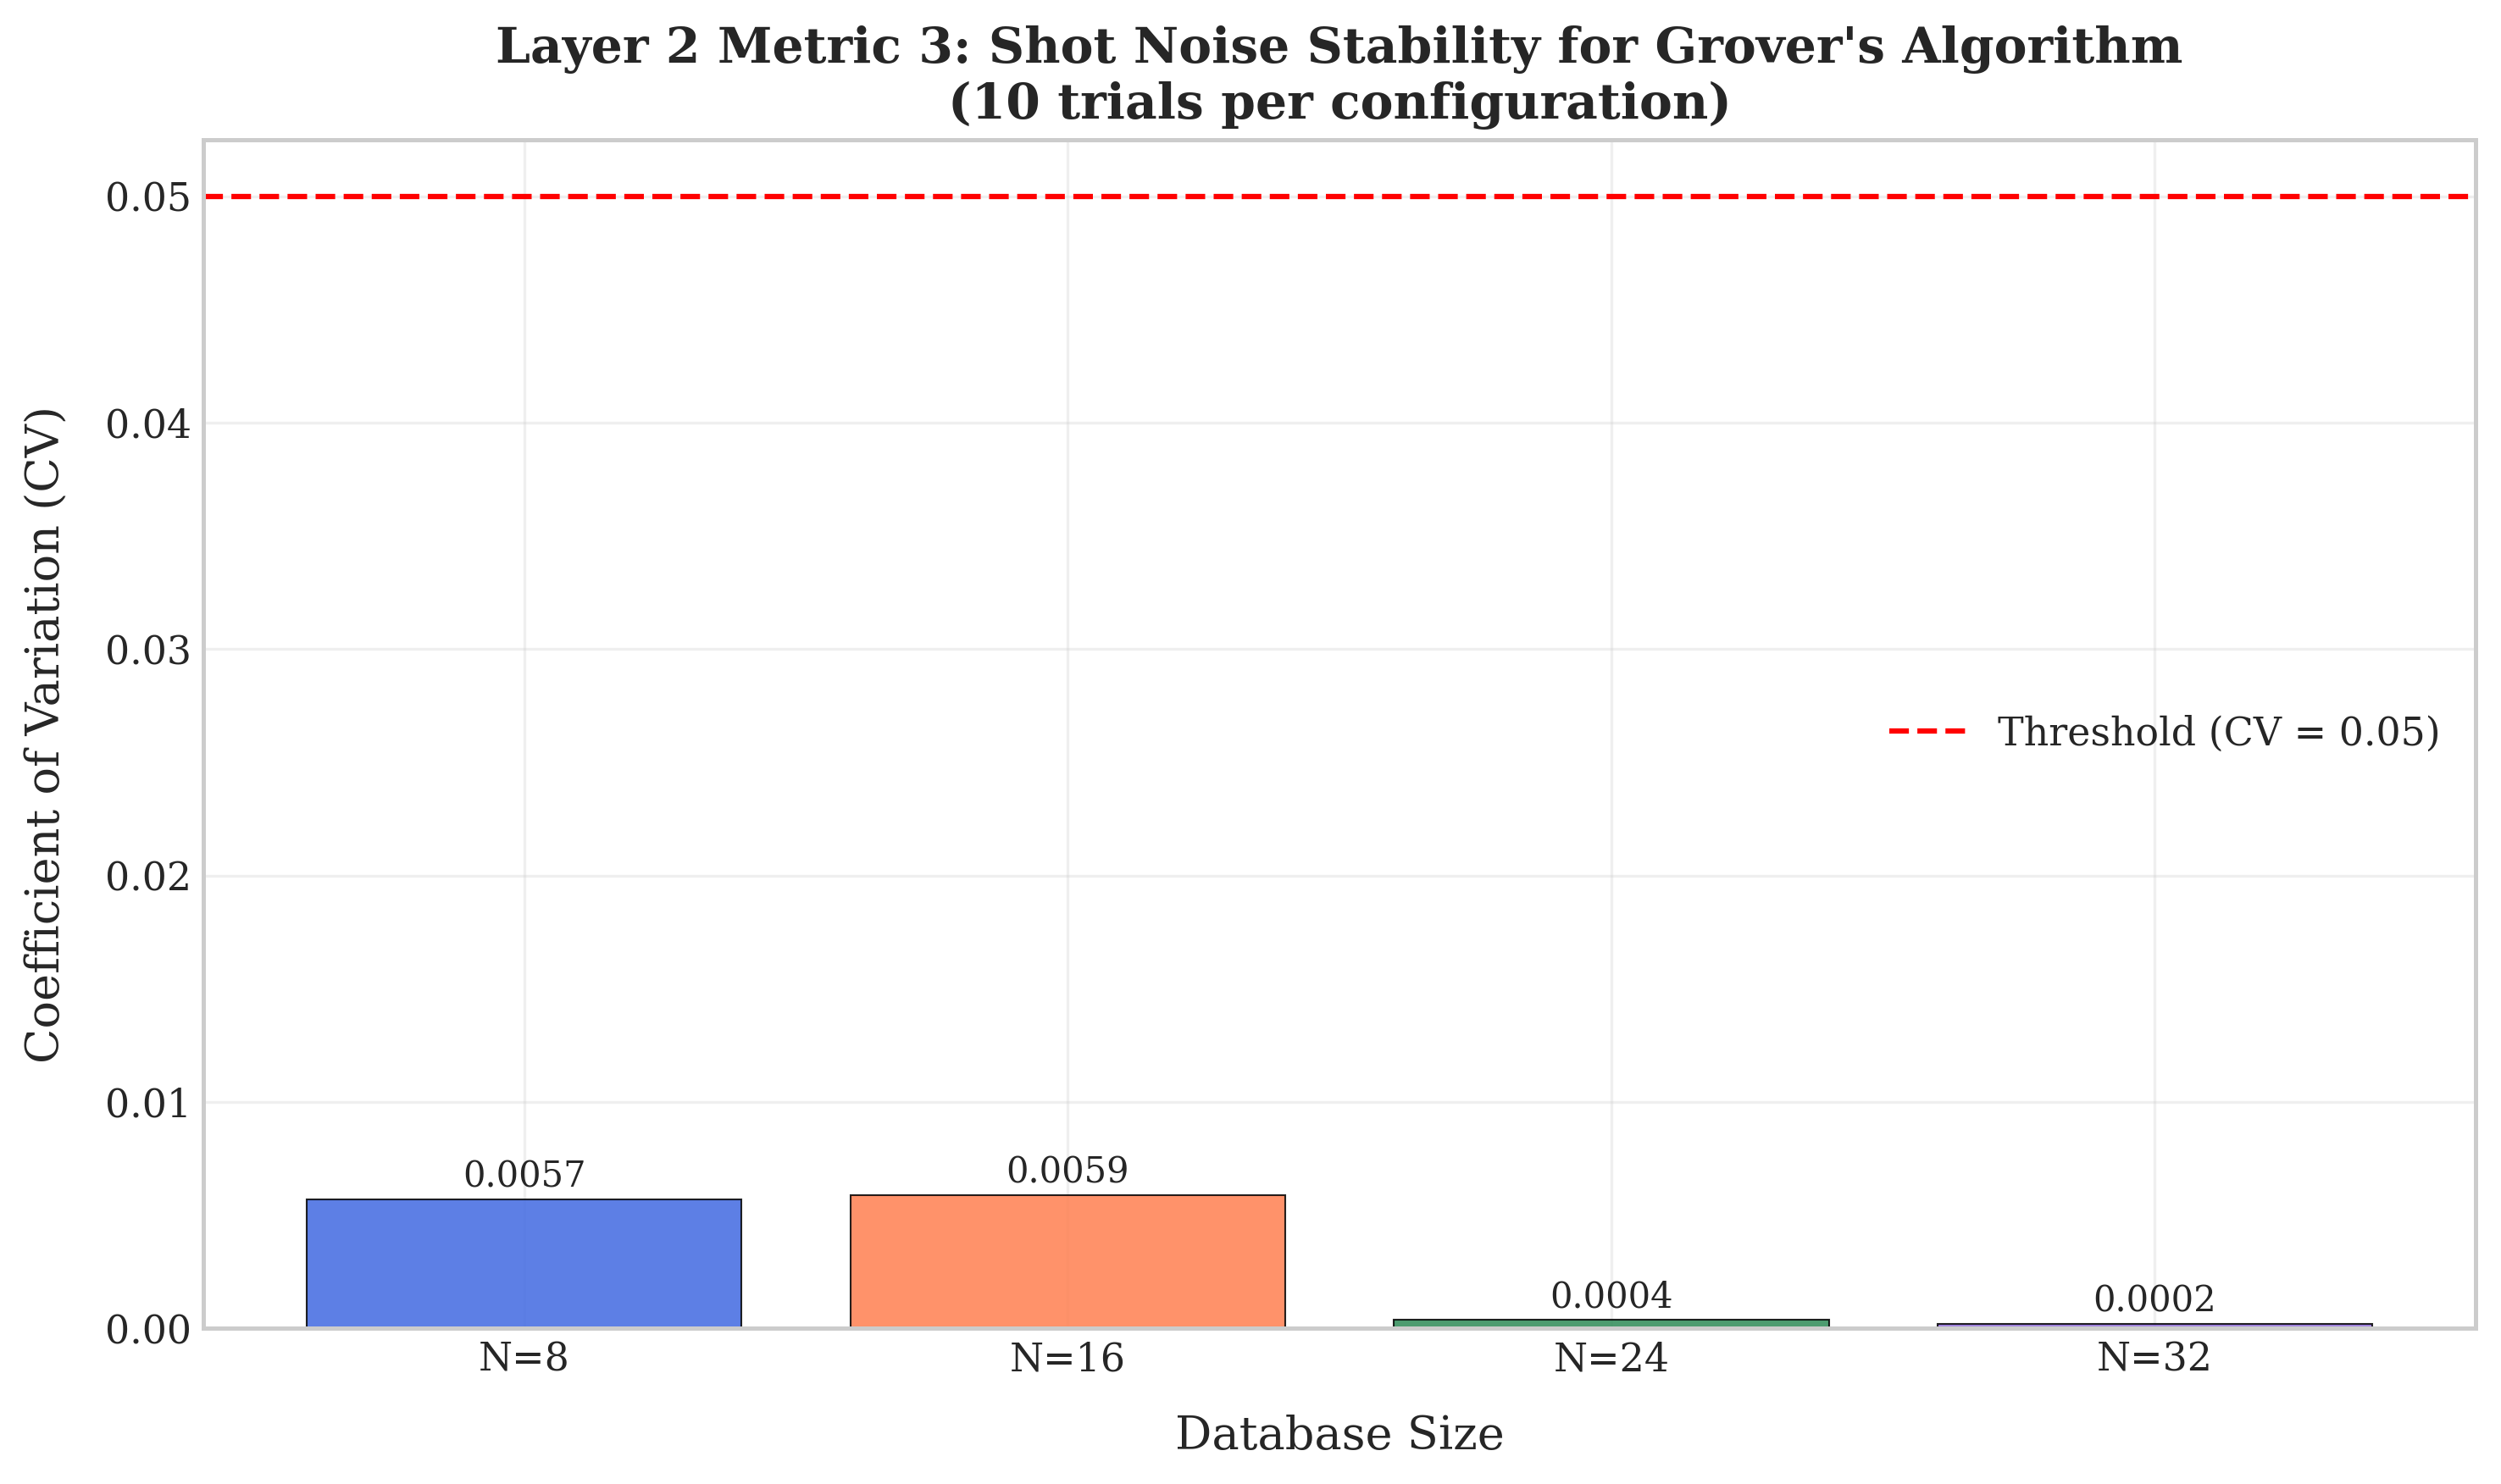

CV plot saved!


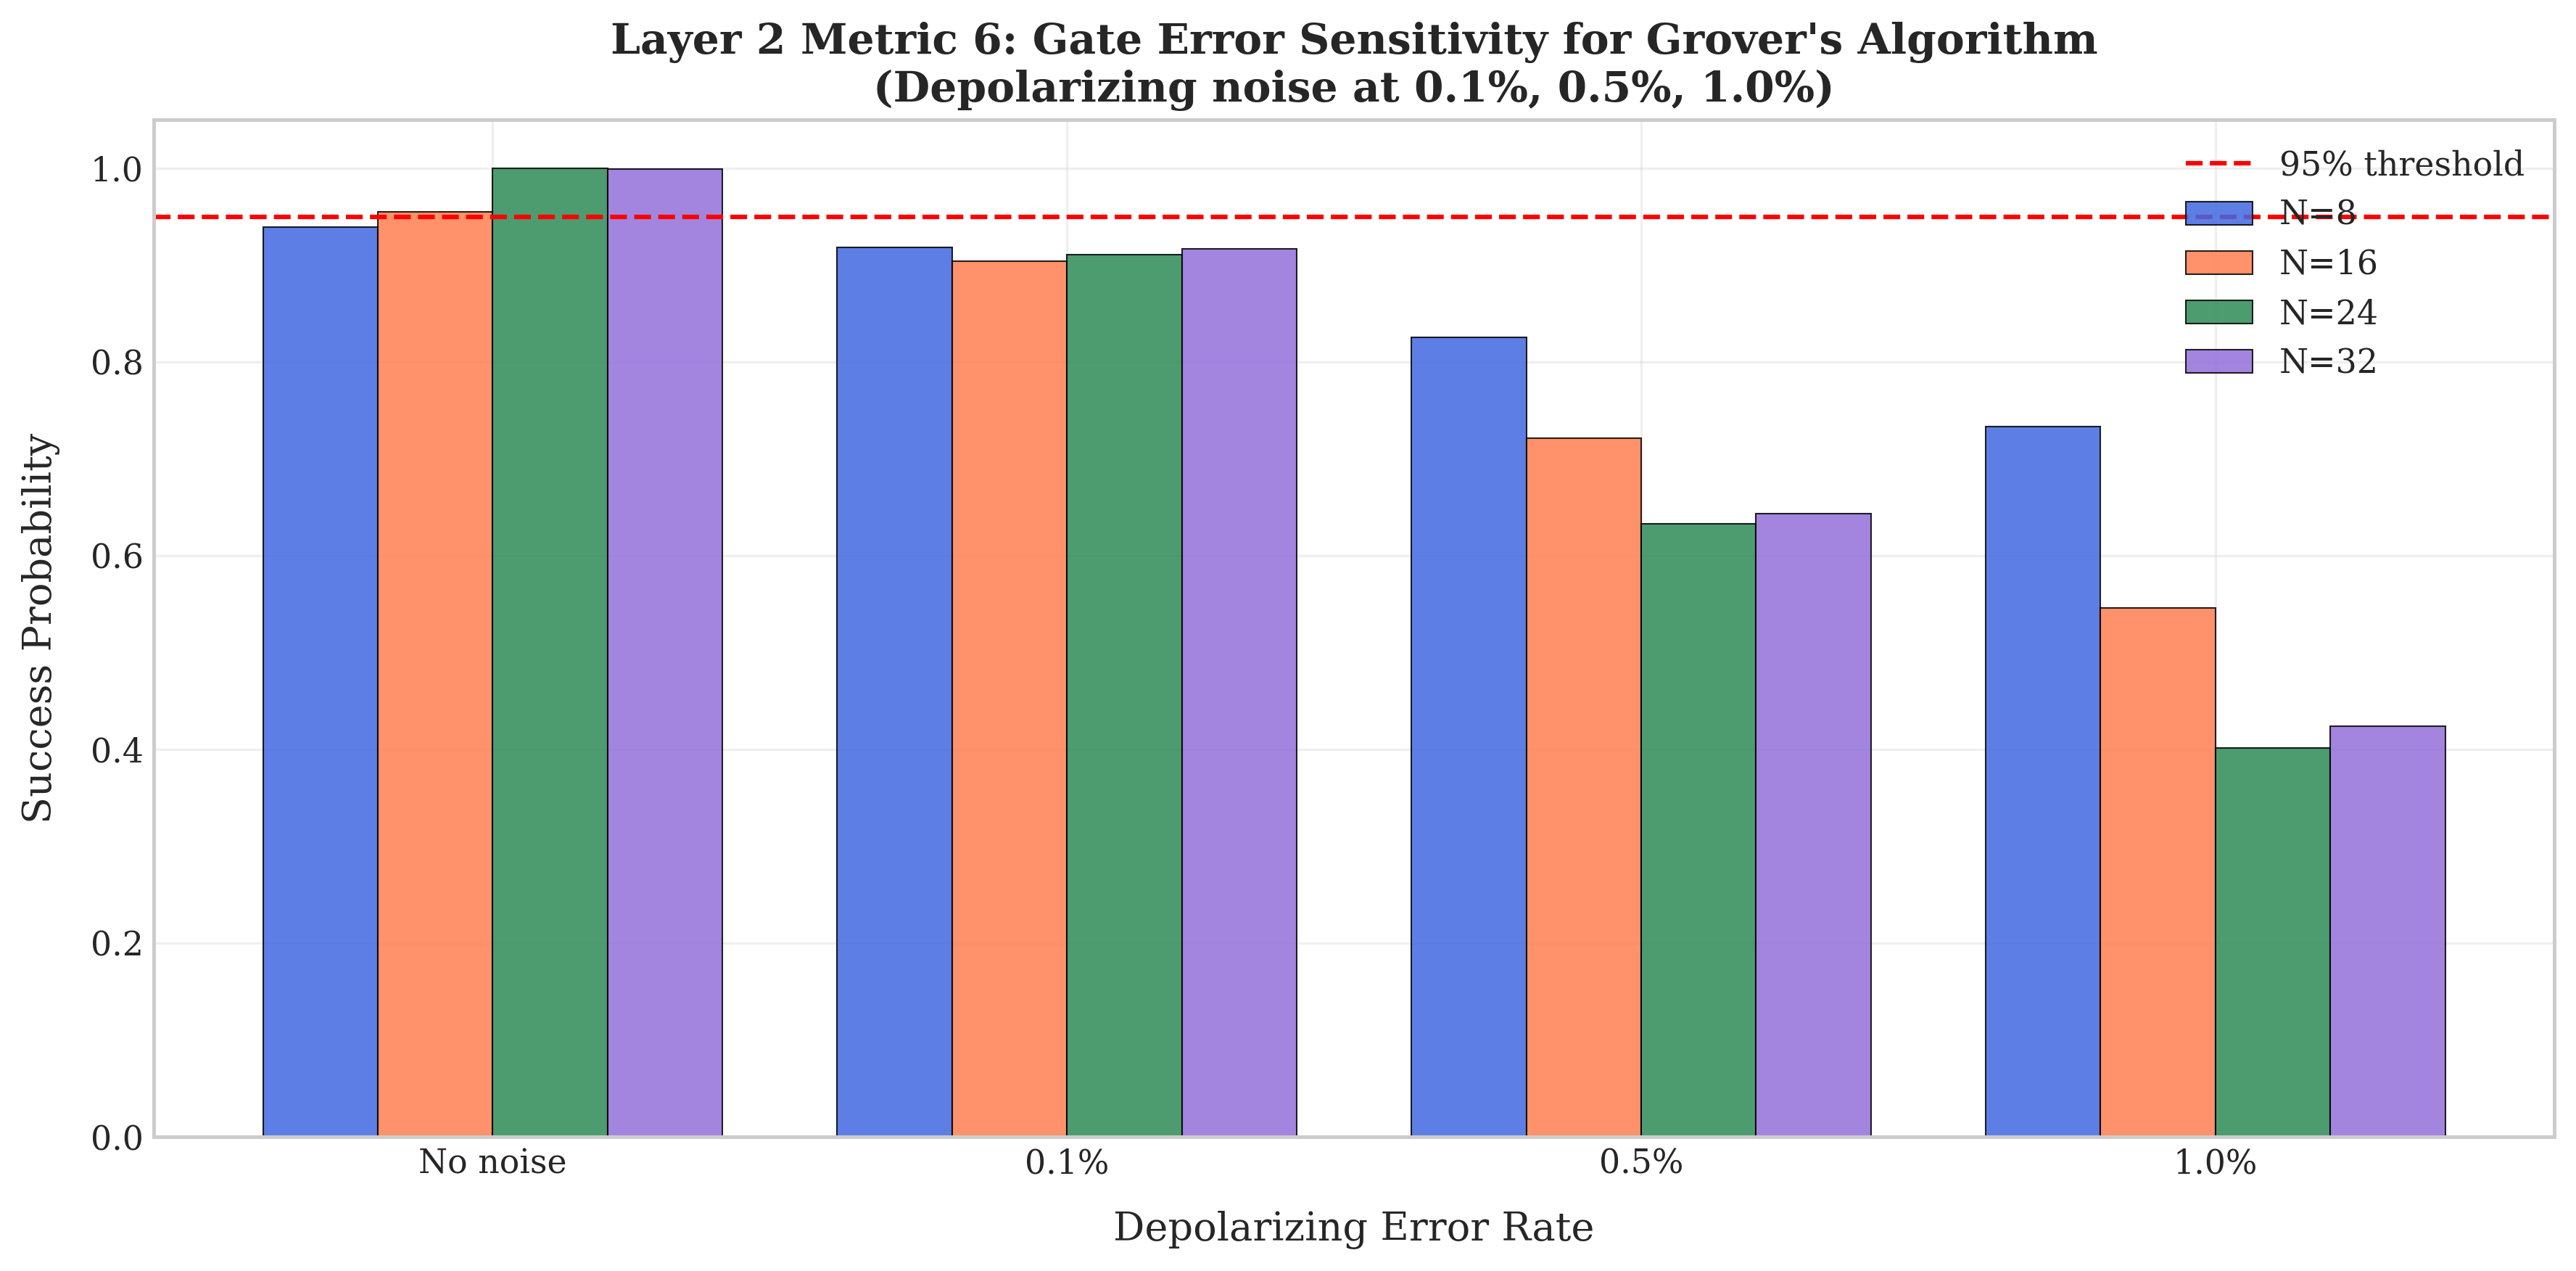

Gate error sensitivity plot saved!


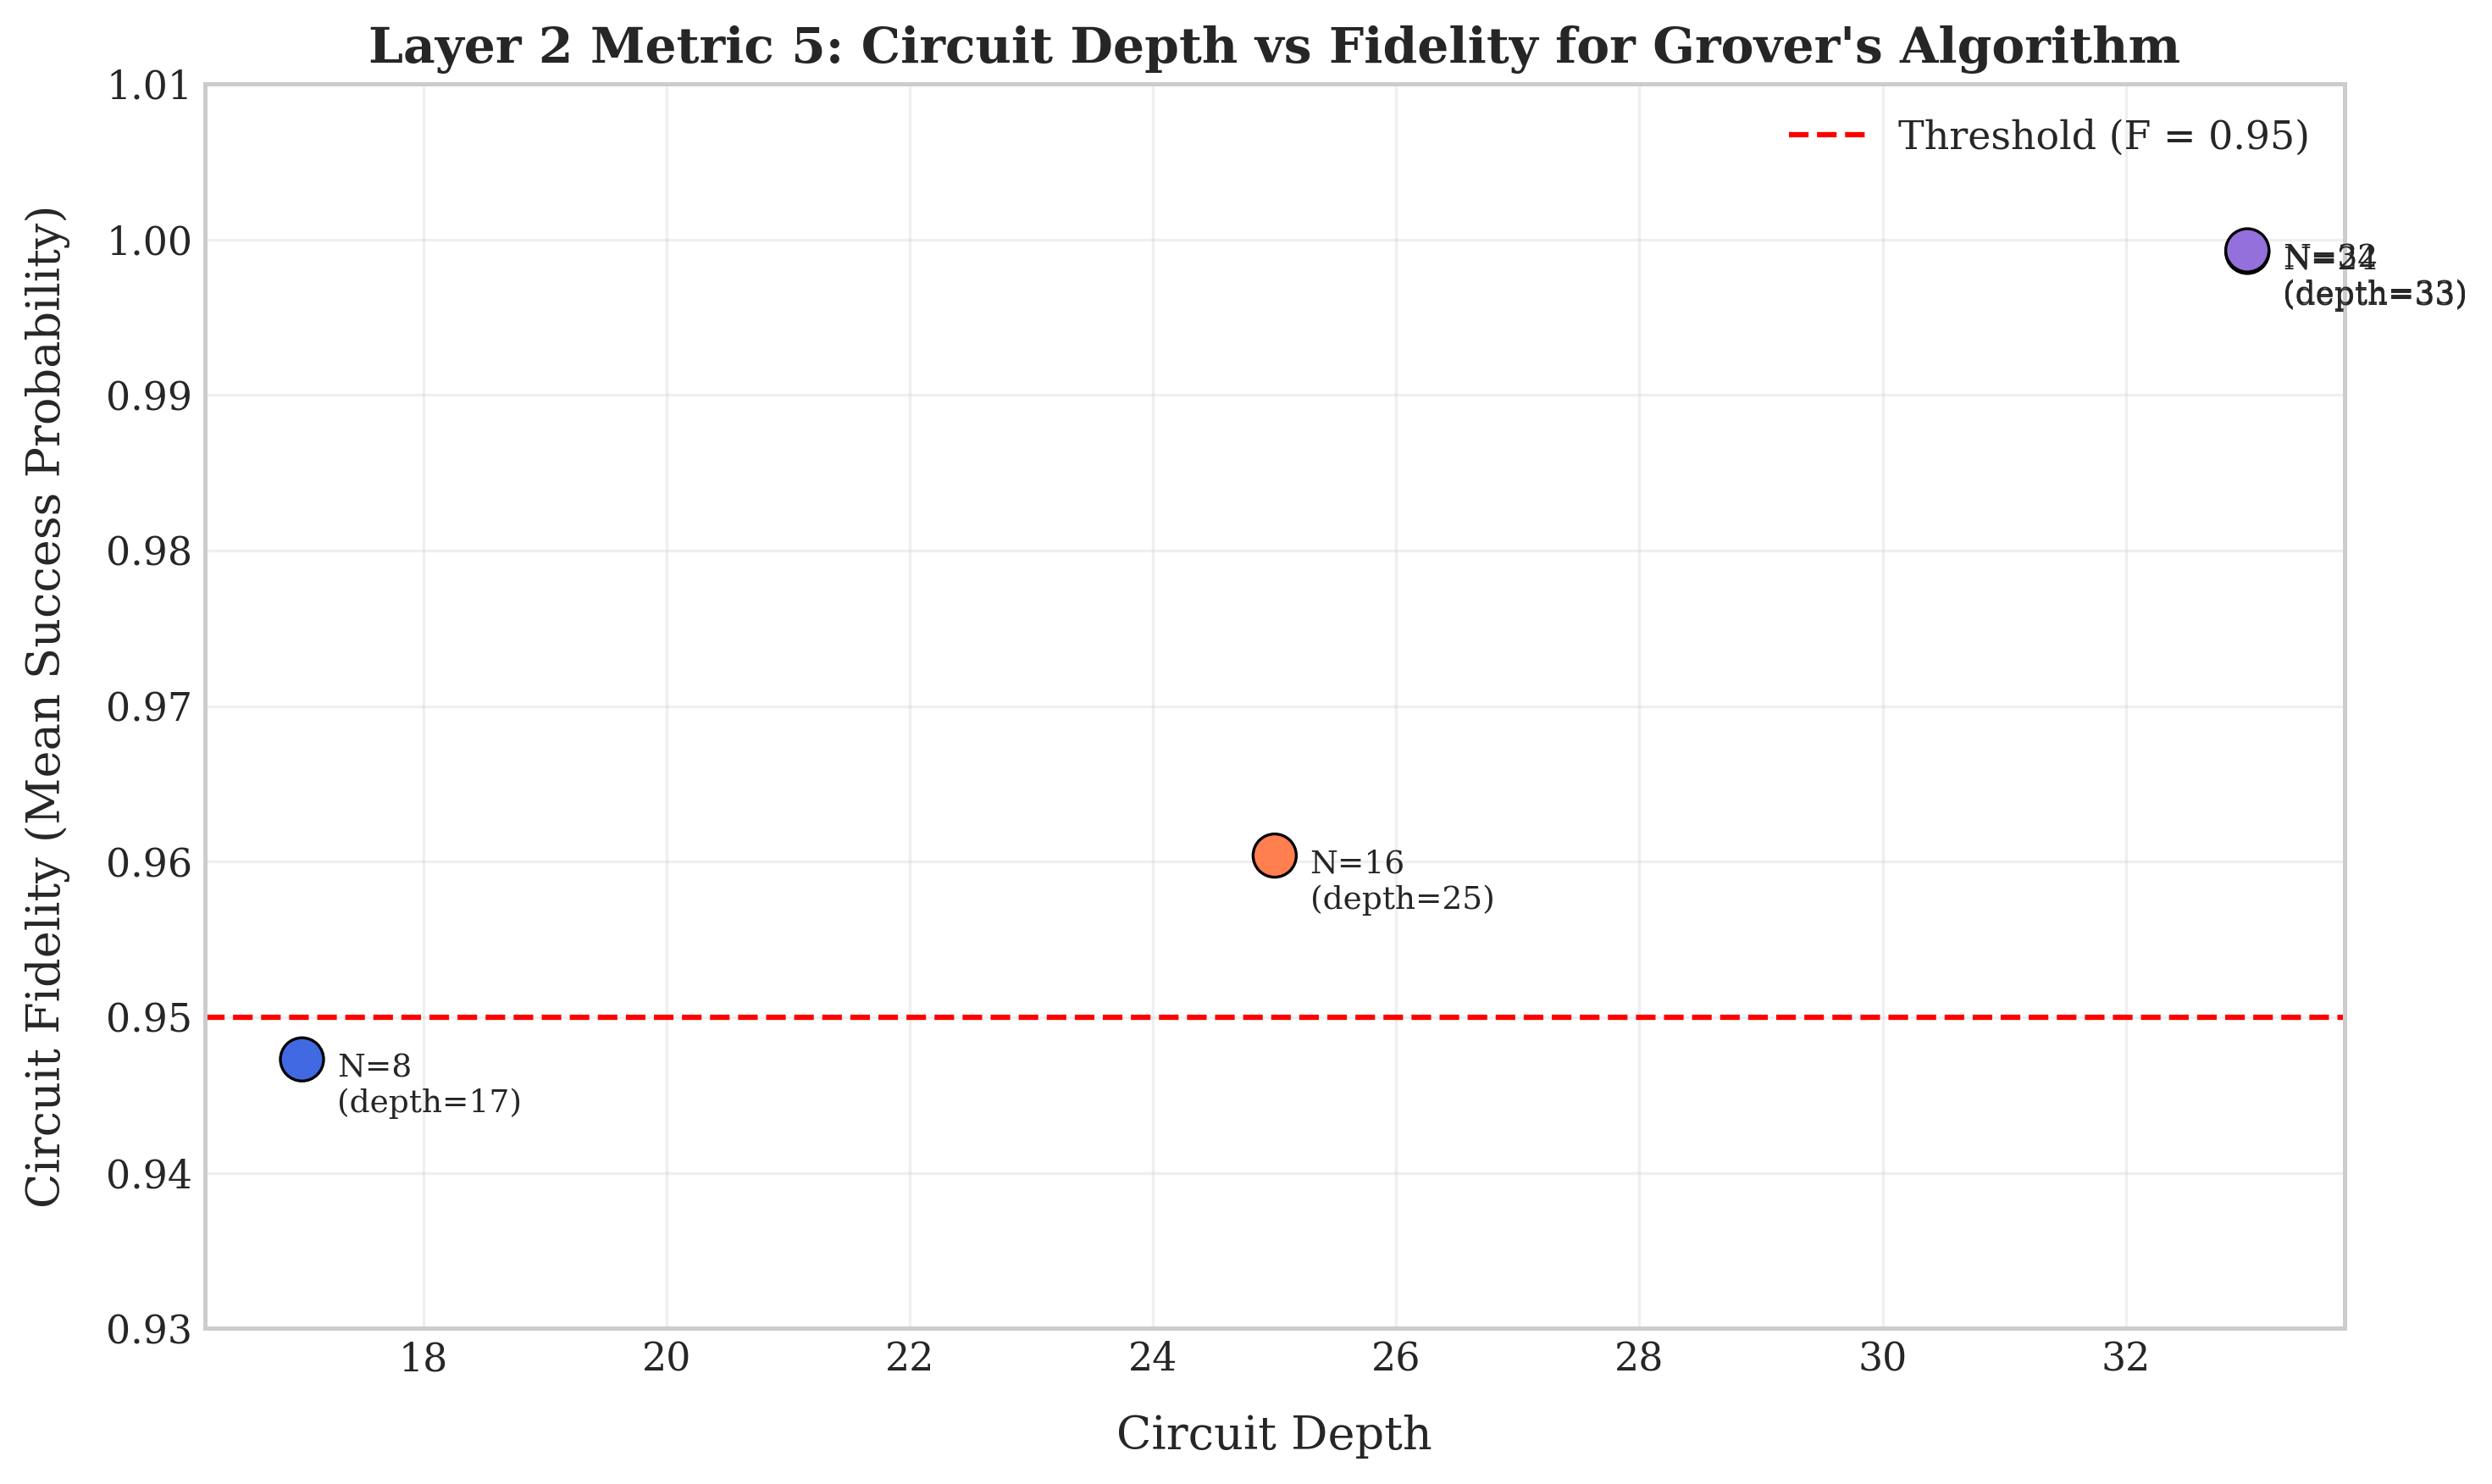

Depth vs fidelity plot saved!


In [25]:
# ── Layer 2 Individual Plots ──────────────────────────────
N_values = [8, 16, 24, 32]
N_labels = ['N=8', 'N=16', 'N=24', 'N=32']
colors = ['royalblue', 'coral', 'seagreen', 'mediumpurple']

# ── Plot 1: Circuit Fidelity ──────────────────────────────
fidelity_values = [0.9473, 0.9604, 0.9992, 0.9993]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(N_labels, fidelity_values, color=colors,
              alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axhline(y=0.95, color='red', linestyle='--',
           linewidth=1.5, label='Threshold (F = 0.95)')
for bar, val, n in zip(bars, fidelity_values, N_values):
    note = '*' if n == 8 else ''
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{val:.4f}{note}', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Database Size', labelpad=10)
ax.set_ylabel('Circuit Fidelity (Mean Success Probability)', labelpad=10)
ax.set_title('Layer 2 Metric 2: Circuit Fidelity for Grover\'s Algorithm\n'
             '(* N=8 is documented theoretical limitation, not simulator issue)',
             fontweight='bold')
ax.set_ylim(0.93, 1.01)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grover_layer2_fidelity.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fidelity plot saved!")

# ── Plot 2: Shot Noise CV ─────────────────────────────────
cv_values = [0.0057, 0.0059, 0.0004, 0.0002]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(N_labels, cv_values, color=colors,
              alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axhline(y=0.05, color='red', linestyle='--',
           linewidth=1.5, label='Threshold (CV = 0.05)')
for bar, val in zip(bars, cv_values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Database Size', labelpad=10)
ax.set_ylabel('Coefficient of Variation (CV)', labelpad=10)
ax.set_title('Layer 2 Metric 3: Shot Noise Stability for Grover\'s Algorithm\n'
             '(10 trials per configuration)',
             fontweight='bold')
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grover_layer2_cv.png', dpi=300, bbox_inches='tight')
plt.show()
print("CV plot saved!")

# ── Plot 3: Gate Error Sensitivity ───────────────────────
error_rates = ['No noise', '0.1%', '0.5%', '1.0%']
n8_sp  = [0.9395, 0.9180, 0.8252, 0.7334]
n16_sp = [0.9551, 0.9043, 0.7217, 0.5459]
n24_sp = [0.9995, 0.9106, 0.6328, 0.4019]
n32_sp = [0.9993, 0.9170, 0.6433, 0.4243]

x = np.arange(len(error_rates))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5*width, n8_sp,  width, label='N=8',  color='royalblue',
       alpha=0.85, edgecolor='black', linewidth=0.5)
ax.bar(x - 0.5*width, n16_sp, width, label='N=16', color='coral',
       alpha=0.85, edgecolor='black', linewidth=0.5)
ax.bar(x + 0.5*width, n24_sp, width, label='N=24', color='seagreen',
       alpha=0.85, edgecolor='black', linewidth=0.5)
ax.bar(x + 1.5*width, n32_sp, width, label='N=32', color='mediumpurple',
       alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axhline(y=0.95, color='red', linestyle='--',
           linewidth=1.5, label='95% threshold')
ax.set_xlabel('Depolarizing Error Rate', labelpad=10)
ax.set_ylabel('Success Probability', labelpad=10)
ax.set_title('Layer 2 Metric 6: Gate Error Sensitivity for Grover\'s Algorithm\n'
             '(Depolarizing noise at 0.1%, 0.5%, 1.0%)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(error_rates)
ax.set_ylim(0, 1.05)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grover_layer2_noise.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gate error sensitivity plot saved!")

# ── Plot 4: Circuit Depth vs Fidelity ────────────────────
depths = [17, 25, 33, 33]
fidelities = [0.9473, 0.9604, 0.9992, 0.9993]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(depths, fidelities, c=colors, s=150,
           edgecolors='black', linewidth=0.8, zorder=5)
for i, (d, f, n) in enumerate(zip(depths, fidelities, N_values)):
    ax.annotate(f'N={n}\n(depth={d})', (d, f),
                textcoords='offset points',
                xytext=(10, -15), fontsize=9)
ax.axhline(y=0.95, color='red', linestyle='--',
           linewidth=1.5, label='Threshold (F = 0.95)')
ax.set_xlabel('Circuit Depth', labelpad=10)
ax.set_ylabel('Circuit Fidelity (Mean Success Probability)', labelpad=10)
ax.set_title('Layer 2 Metric 5: Circuit Depth vs Fidelity for Grover\'s Algorithm',
             fontweight='bold')
ax.set_ylim(0.93, 1.01)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grover_layer2_depth.png', dpi=300, bbox_inches='tight')
plt.show()
print("Depth vs fidelity plot saved!")

### Performance Analysis

In [27]:
# ── Performance Analysis for Grover's ────────────────────
import psutil

print(f"{'N':>4} | {'Iters':>5} | {'Time(s)':>8} | {'Queries/s':>10} | {'CPU(s)':>8}")
print("-" * 55)

grover_perf_results = []
process = psutil.Process()

for N in DATABASE_SIZES:
    n_qubits = QUBITS[N]
    shots = SHOTS[N]
    n_iter = OPTIMAL_ITERATIONS[N]
    target = np.random.randint(0, N)

    # Measure CPU time
    cpu_before = process.cpu_times()
    start = time.time()
    result = run_grover(n_qubits, target, shots, n_iter)
    runtime = time.time() - start
    cpu_after = process.cpu_times()

    cpu_time = round((cpu_after.user - cpu_before.user) +
                     (cpu_after.system - cpu_before.system), 4)

    # Throughput = queries per second
    # Each shot = 1 query to the oracle
    throughput = round(shots / runtime, 2)

    grover_perf_results.append({
        'N': N,
        'n_iterations': n_iter,
        'shots': shots,
        'runtime_seconds': round(runtime, 4),
        'throughput_qps': throughput,
        'cpu_time_seconds': cpu_time,
        'success_probability': result['success_probability']
    })

    print(f"{N:>4} | {n_iter:>5} | {runtime:>8.4f} | "
          f"{throughput:>10.2f} | {cpu_time:>8.4f}")

print("-" * 55)
print("Throughput = shots per second (oracle queries/second)")

   N | Iters |  Time(s) |  Queries/s |   CPU(s)
-------------------------------------------------------


   8 |     2 |   0.5799 |    1765.76 |   0.5800
  16 |     3 |   0.0354 |   28928.18 |   0.0300
  24 |     4 |   0.1256 |   65220.40 |   0.1200


  32 |     4 |   0.1553 |   52760.49 |   0.1500
-------------------------------------------------------
Throughput = shots per second (oracle queries/second)


### Performance Visualization

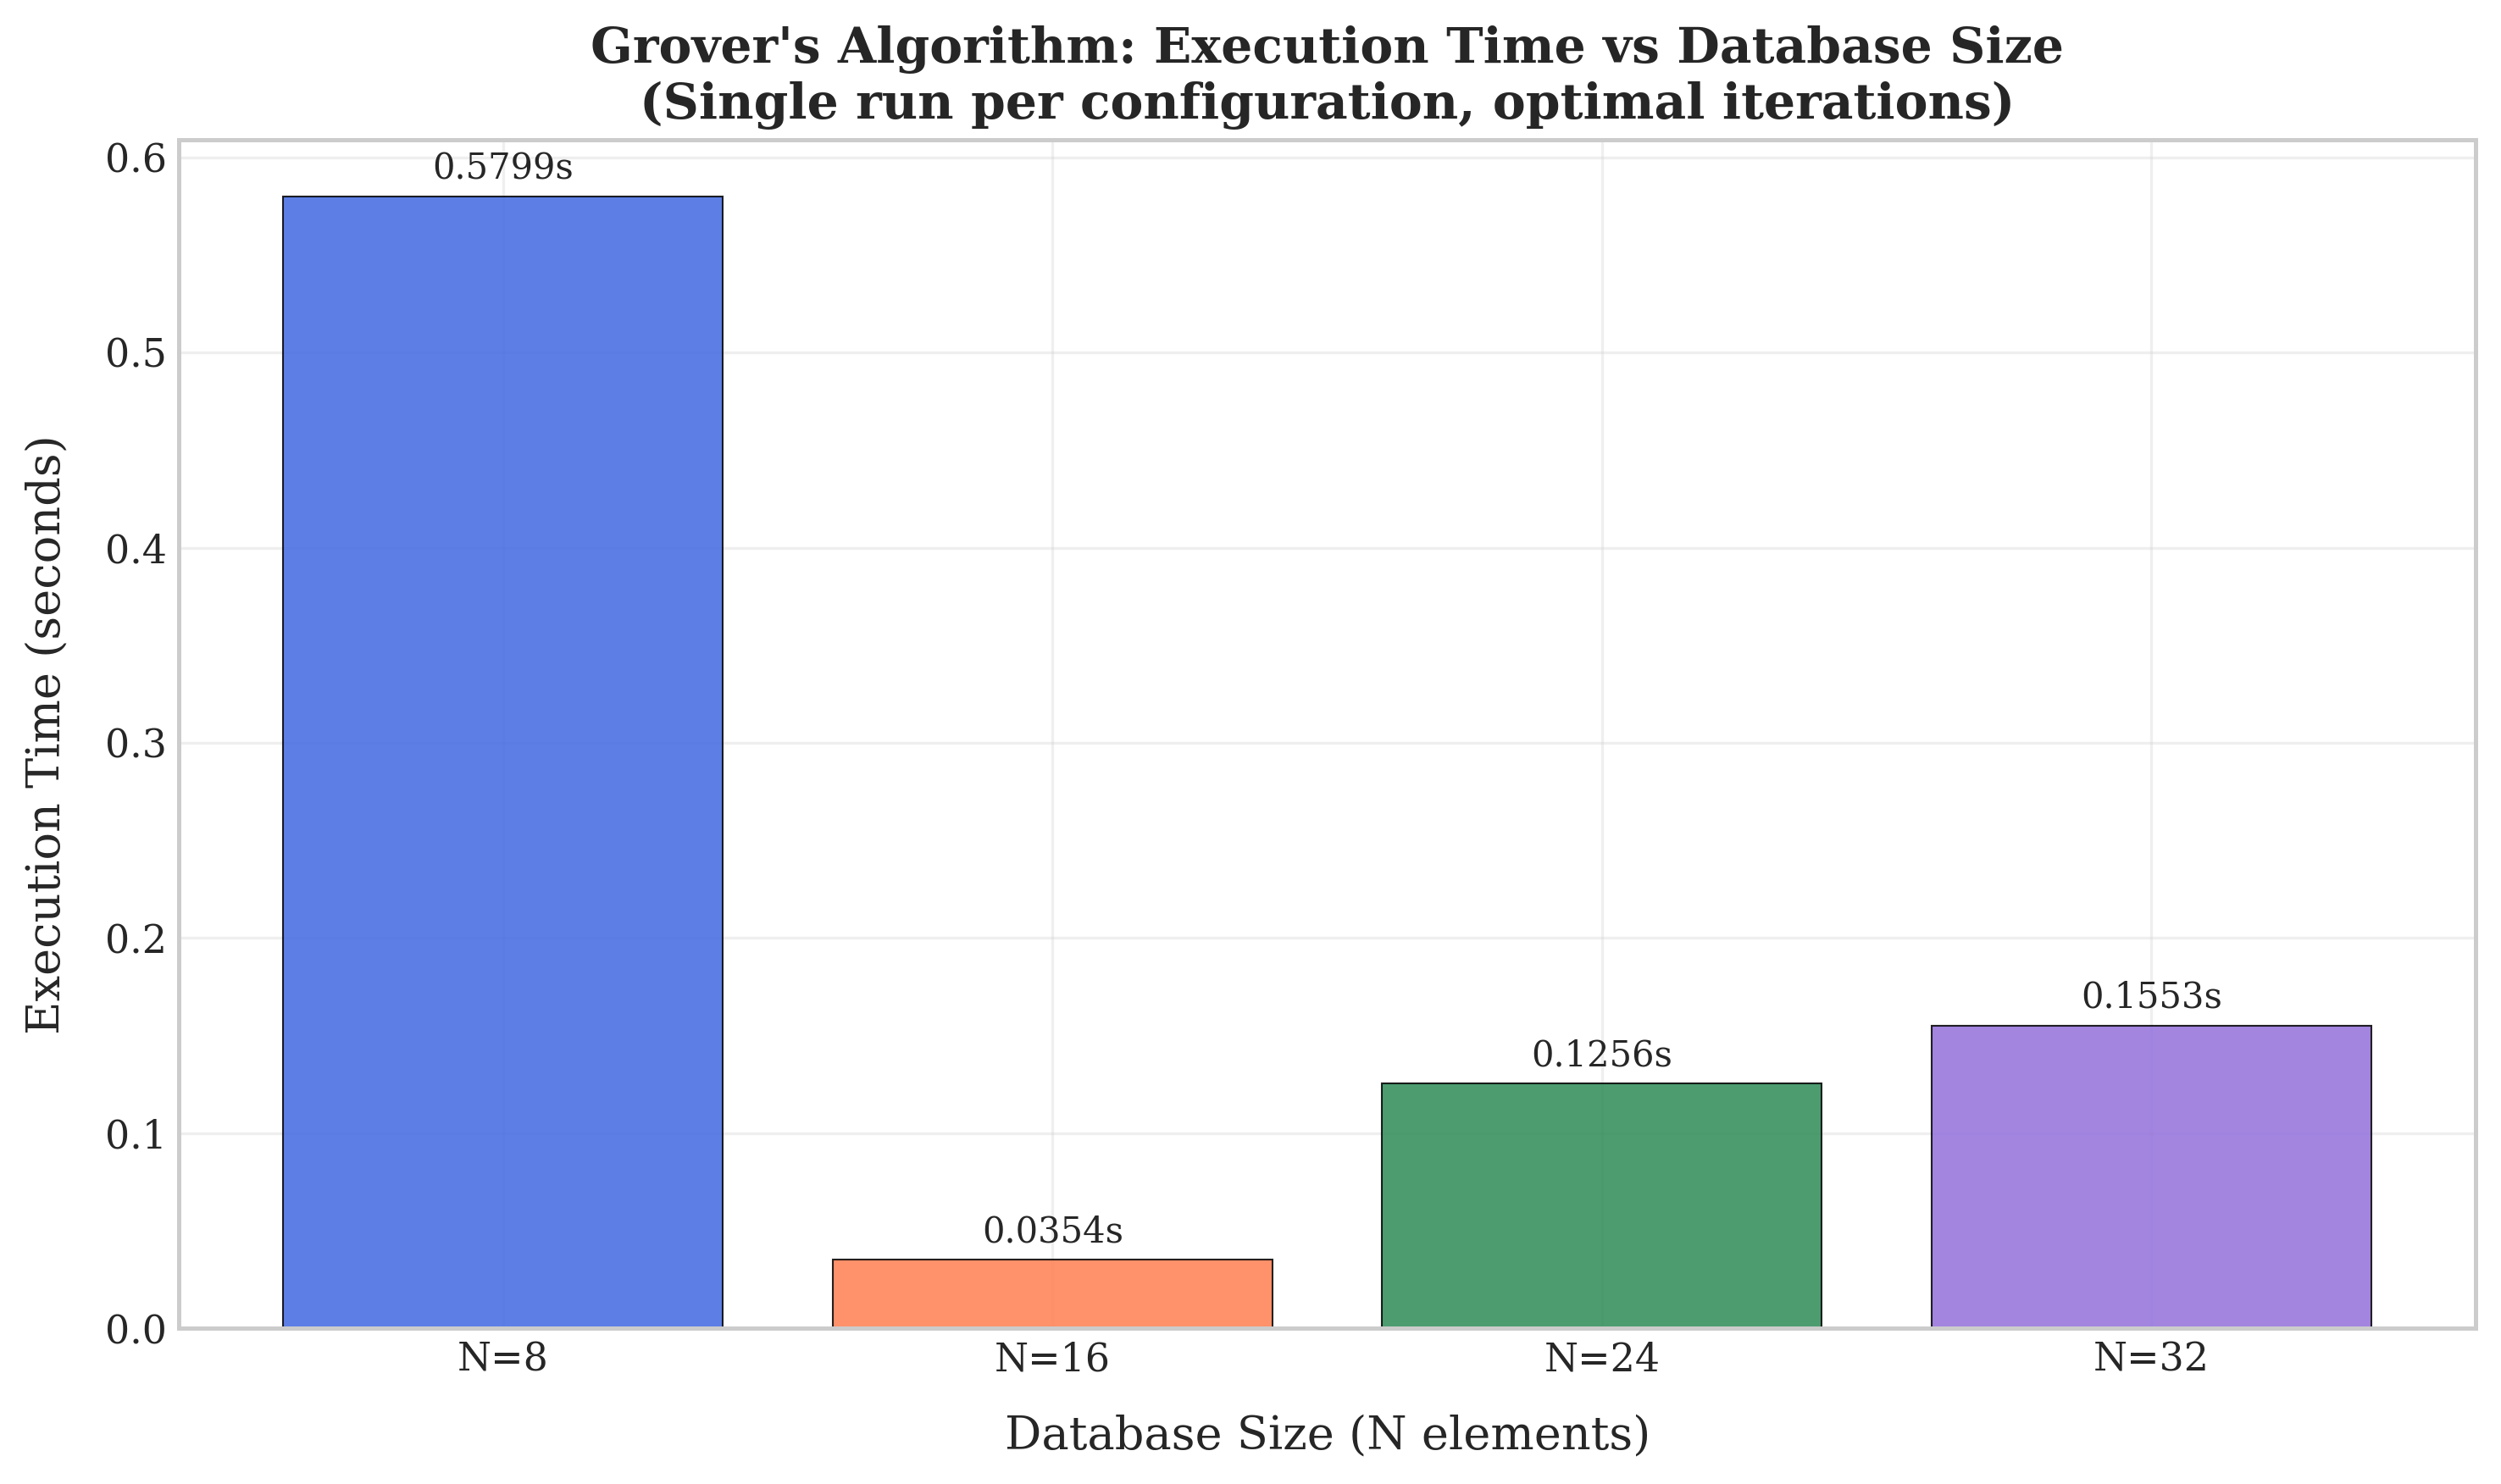

Execution time plot saved!


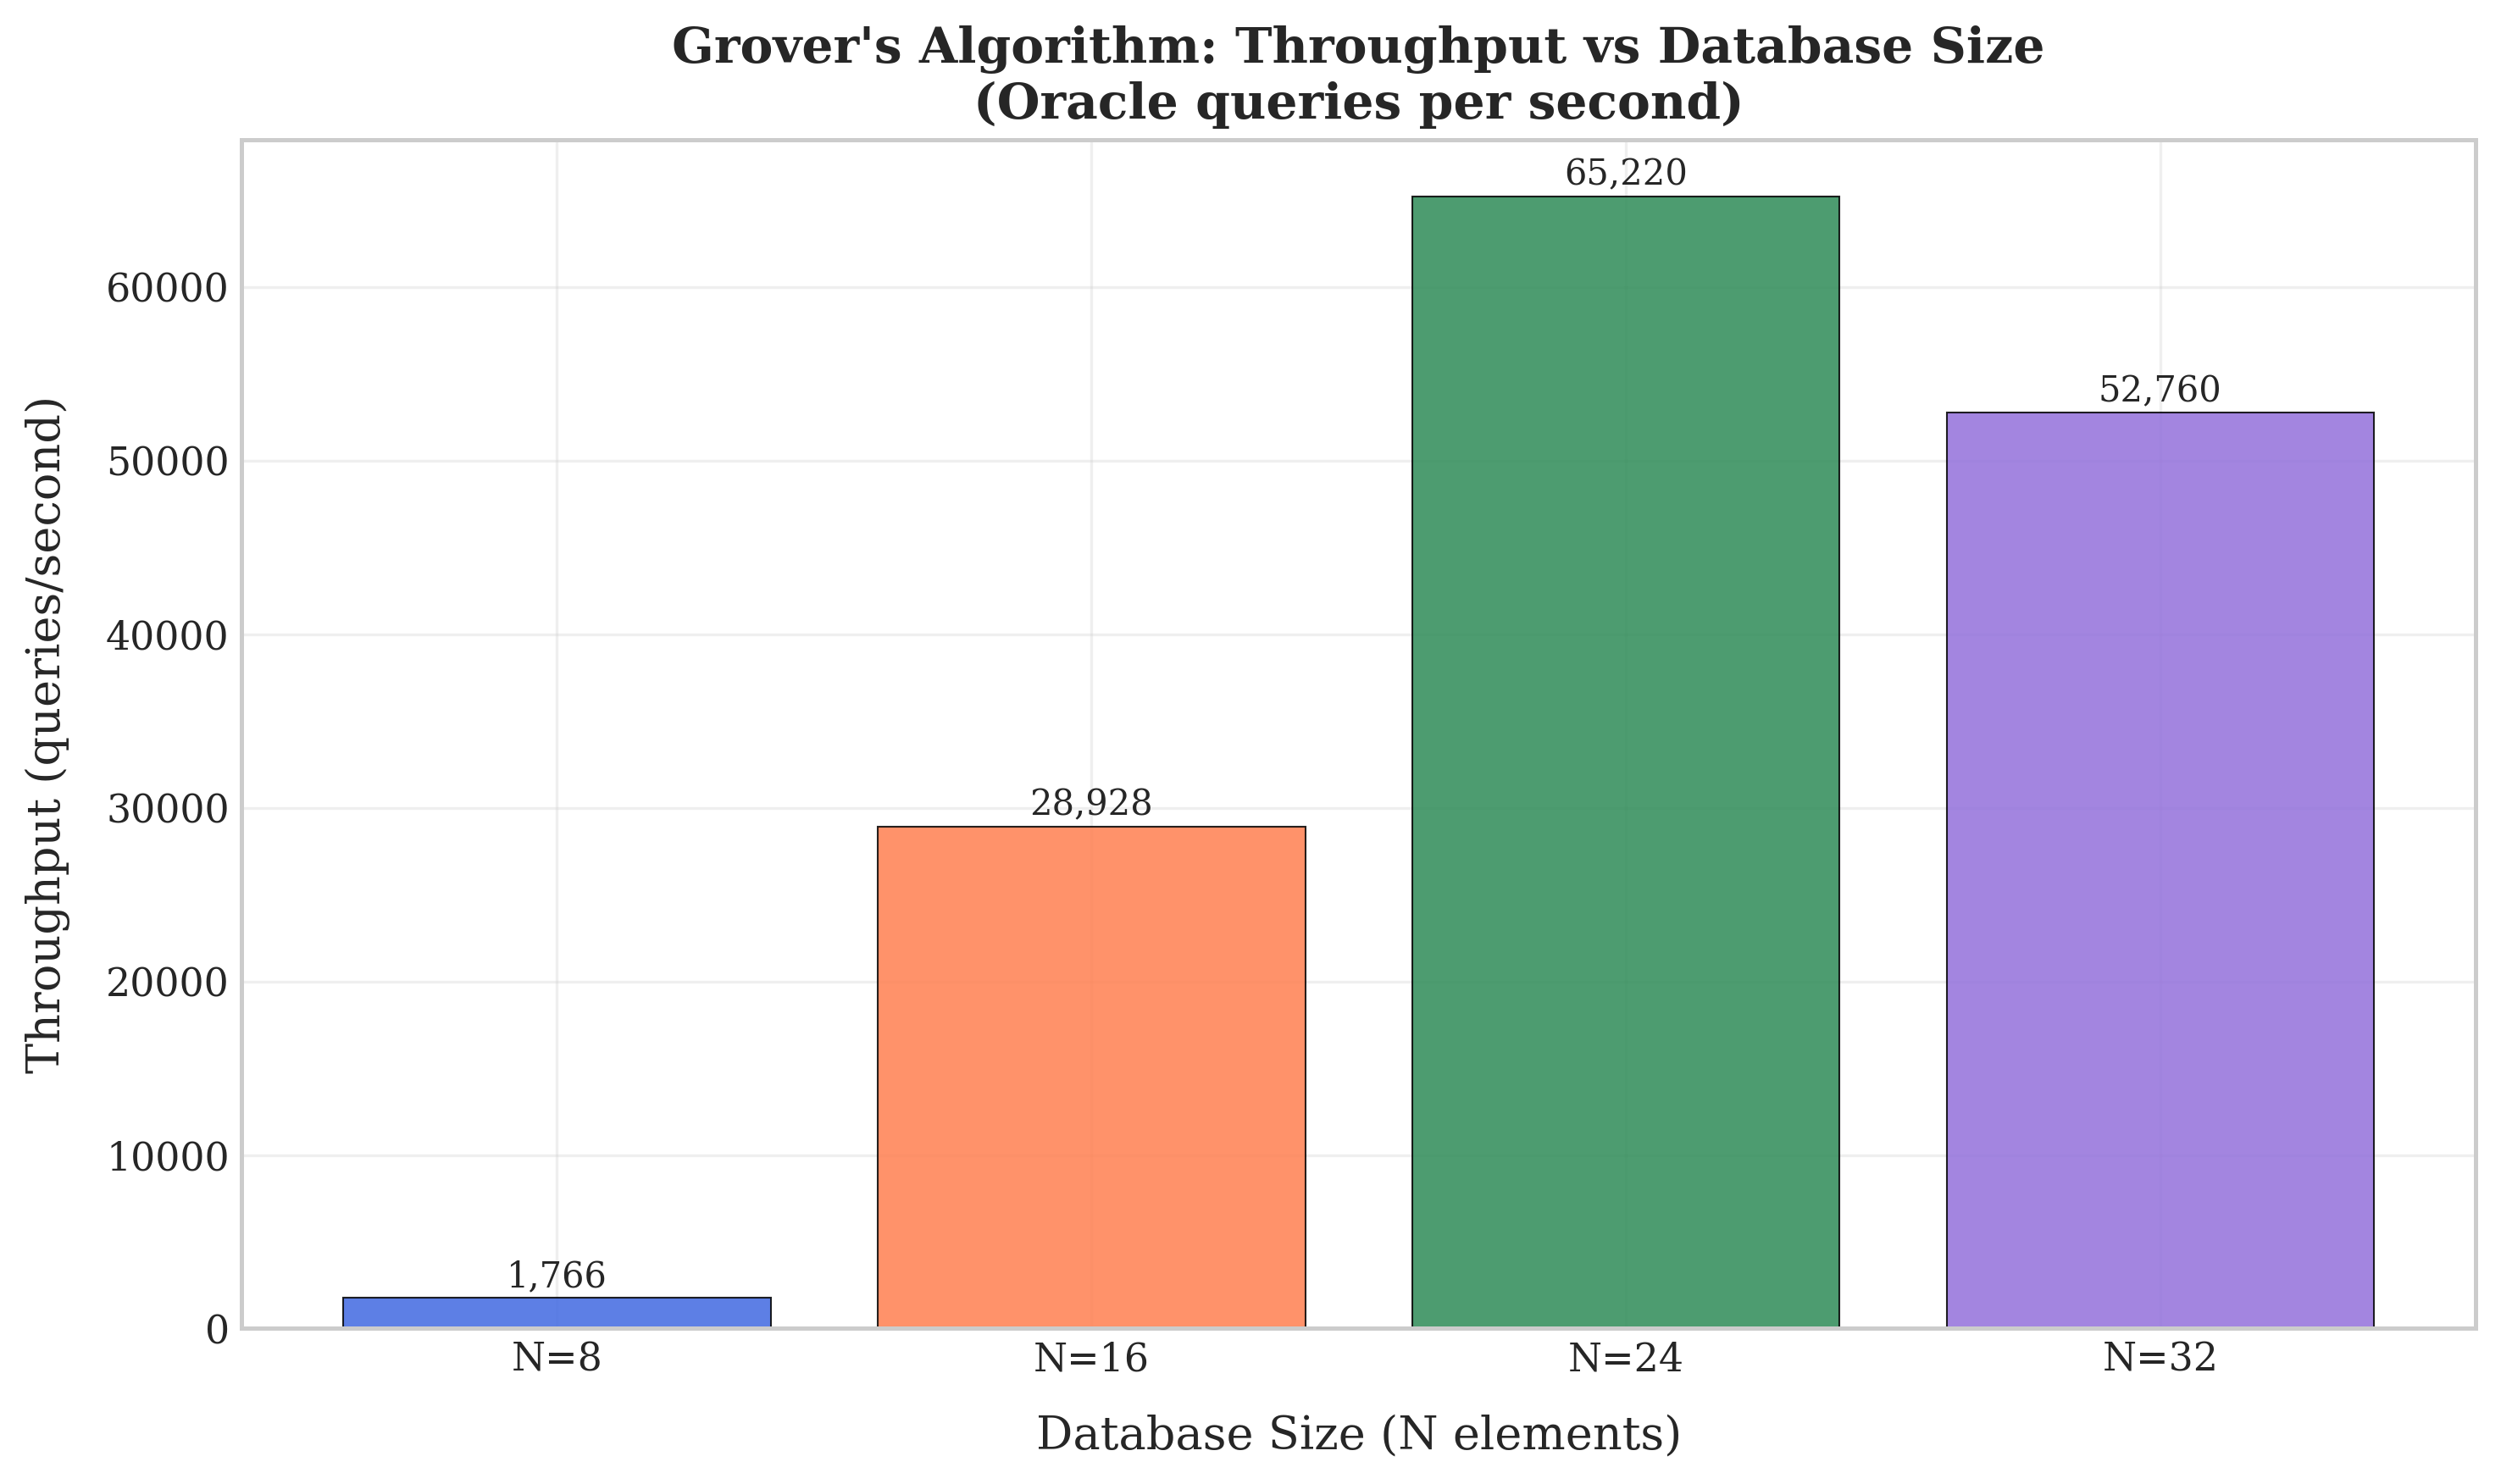

Throughput plot saved!


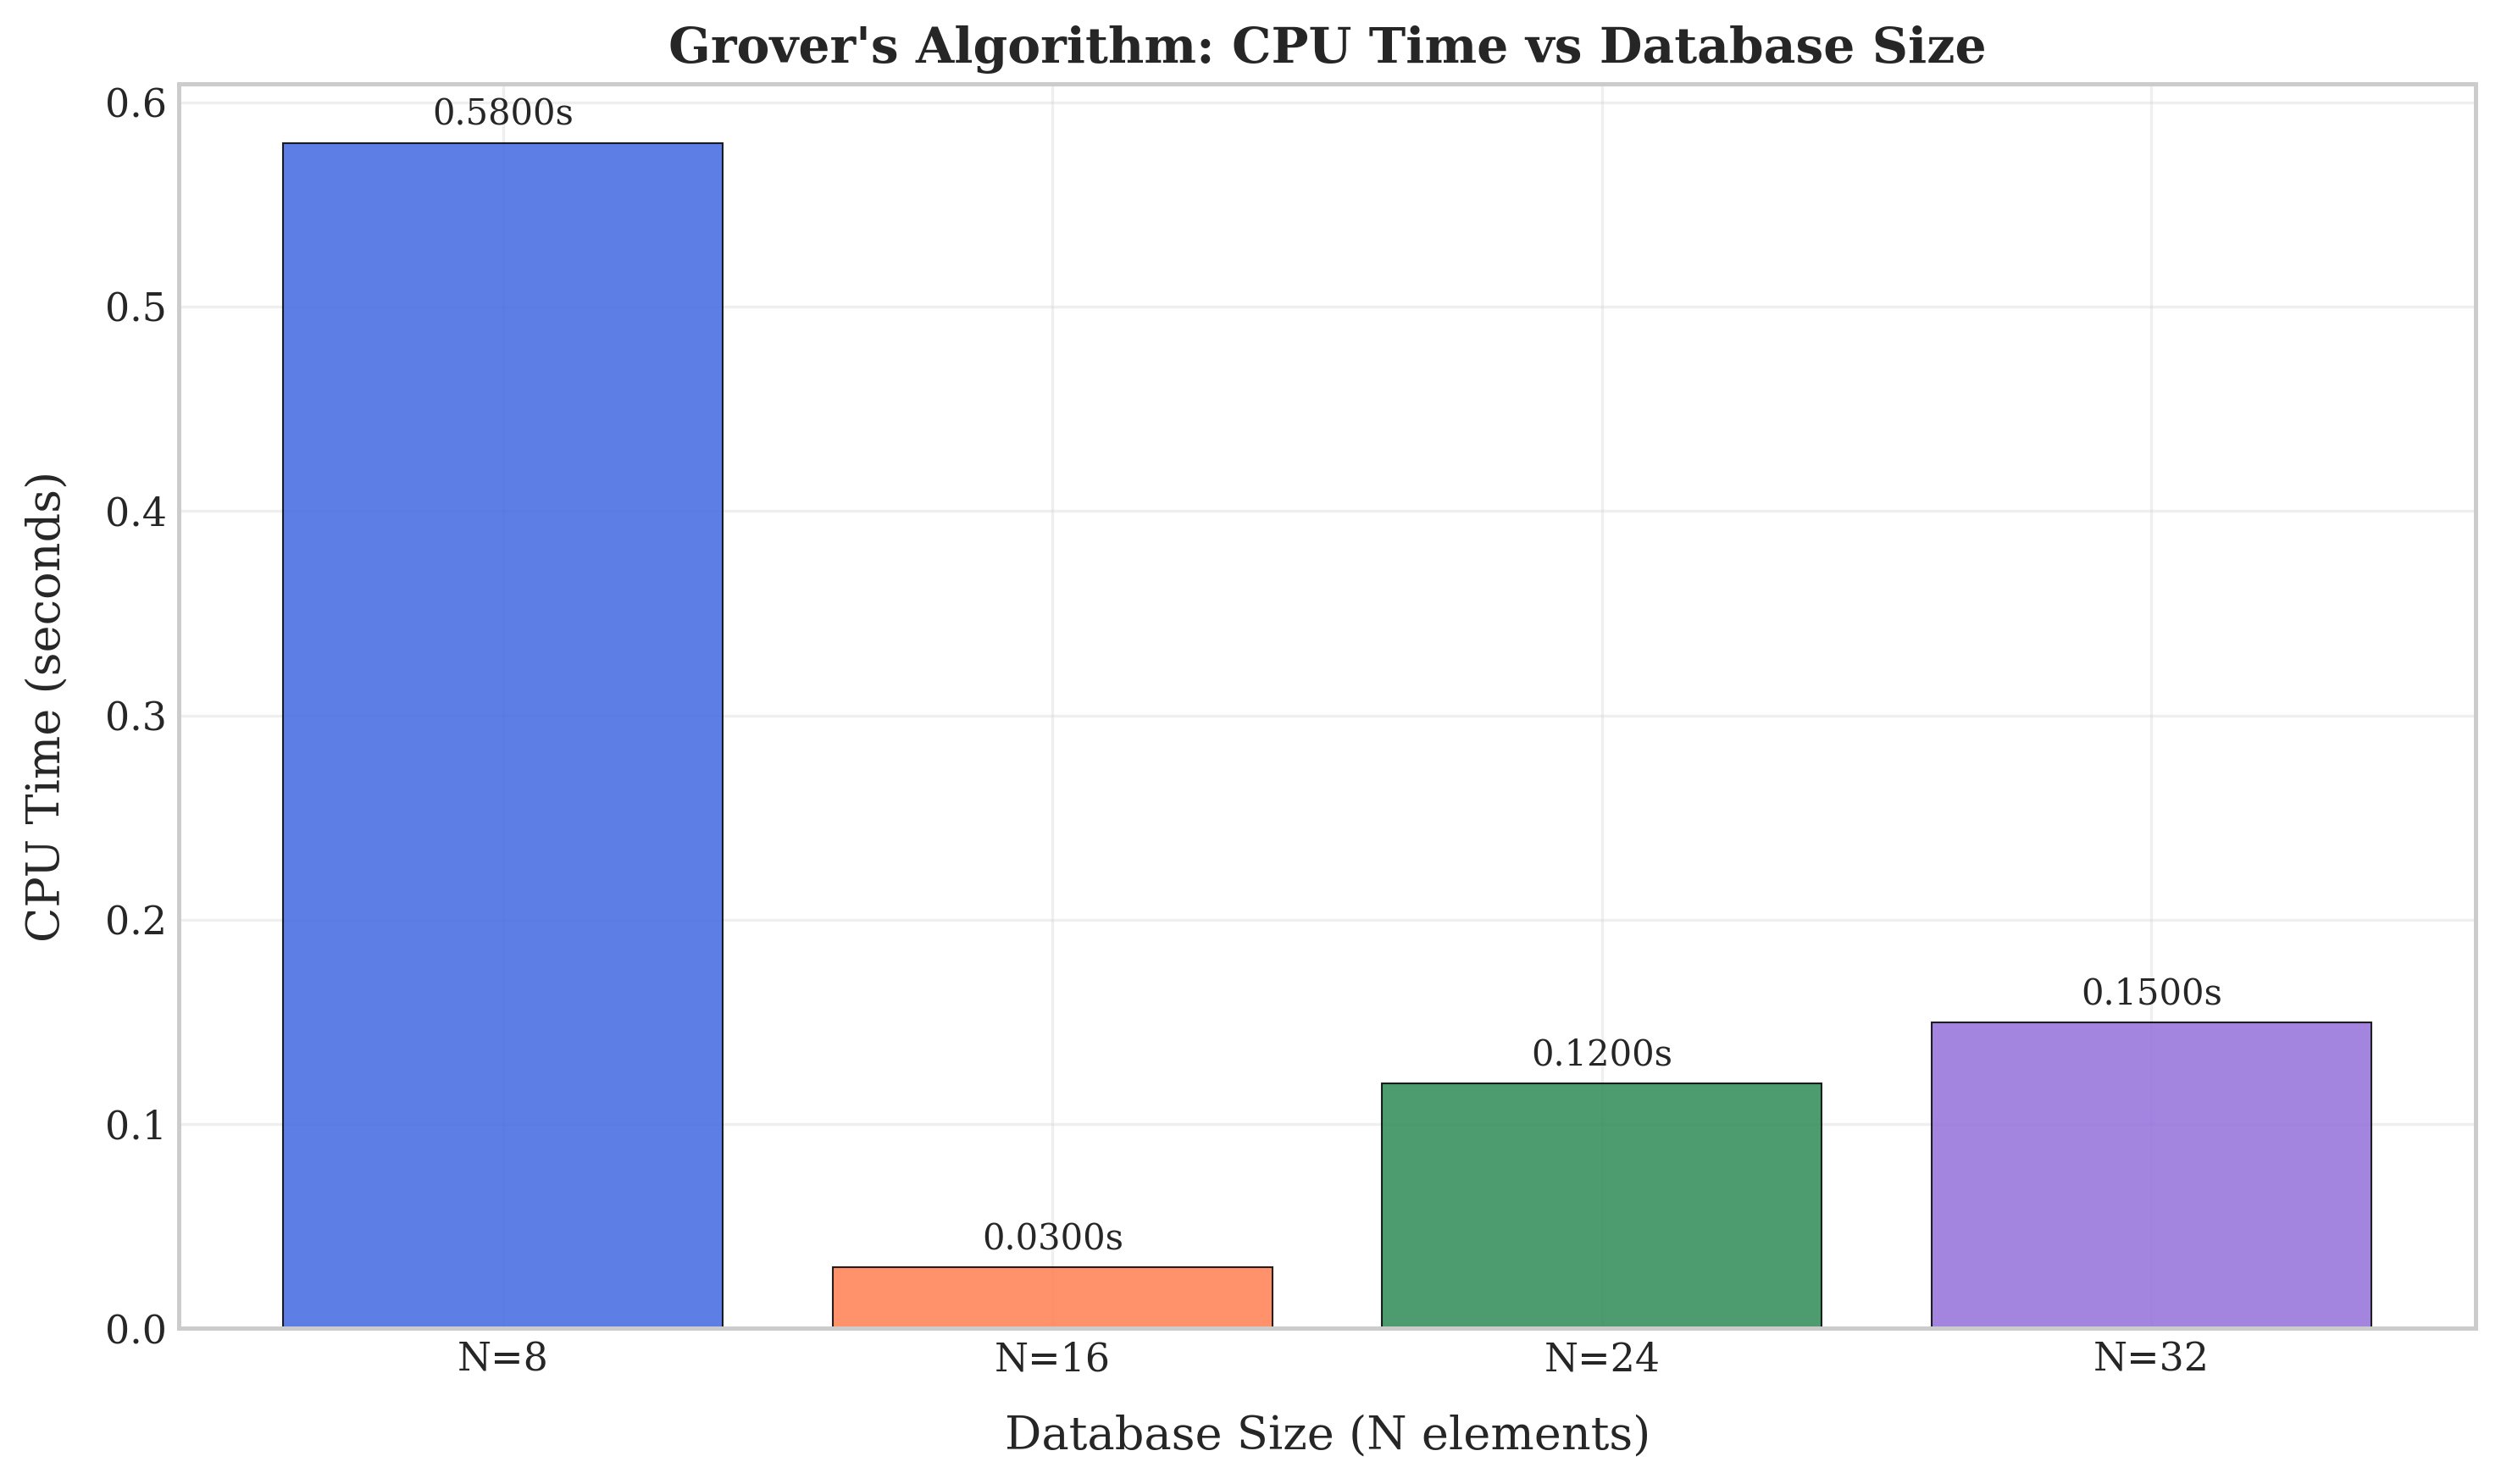

CPU time plot saved!


In [28]:
# ── Plot 1: Runtime Scaling ───────────────────────────────
N_values = [r['N'] for r in grover_perf_results]
runtimes = [r['runtime_seconds'] for r in grover_perf_results]
throughputs = [r['throughput_qps'] for r in grover_perf_results]
cpu_times = [r['cpu_time_seconds'] for r in grover_perf_results]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar([f'N={n}' for n in N_values], runtimes,
              color=['royalblue', 'coral', 'seagreen', 'mediumpurple'],
              alpha=0.85, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, runtimes):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.4f}s', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Database Size (N elements)', labelpad=10)
ax.set_ylabel('Execution Time (seconds)', labelpad=10)
ax.set_title("Grover's Algorithm: Execution Time vs Database Size\n"
             "(Single run per configuration, optimal iterations)",
             fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grover_performance_time.png', dpi=300, bbox_inches='tight')
plt.show()
print("Execution time plot saved!")

# ── Plot 2: Throughput ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar([f'N={n}' for n in N_values], throughputs,
              color=['royalblue', 'coral', 'seagreen', 'mediumpurple'],
              alpha=0.85, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, throughputs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Database Size (N elements)', labelpad=10)
ax.set_ylabel('Throughput (queries/second)', labelpad=10)
ax.set_title("Grover's Algorithm: Throughput vs Database Size\n"
             "(Oracle queries per second)",
             fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grover_performance_throughput.png', dpi=300, bbox_inches='tight')
plt.show()
print("Throughput plot saved!")

# ── Plot 3: CPU Time ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar([f'N={n}' for n in N_values], cpu_times,
              color=['royalblue', 'coral', 'seagreen', 'mediumpurple'],
              alpha=0.85, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, cpu_times):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.4f}s', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Database Size (N elements)', labelpad=10)
ax.set_ylabel('CPU Time (seconds)', labelpad=10)
ax.set_title("Grover's Algorithm: CPU Time vs Database Size",
             fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grover_performance_cpu.png', dpi=300, bbox_inches='tight')
plt.show()
print("CPU time plot saved!")

In [29]:
# ── Experiment Log 003: Performance Analysis ─────────────
experiment_log_grover_003 = {
    "experiment_id": "qi26_26_Grover_003",
    "benchmark_type": "Grover_Performance",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "protocol": {
        "database_sizes": [8, 16, 24, 32],
        "optimal_iterations": {"8": 2, "16": 3, "24": 4, "32": 4},
        "shots": {"8": 1024, "16": 1024, "24": 8192, "32": 8192}
    },
    "metrics": {
        "performance": [
            {
                "N": r['N'],
                "n_iterations": r['n_iterations'],
                "shots": r['shots'],
                "runtime_seconds": r['runtime_seconds'],
                "throughput_qps": r['throughput_qps'],
                "cpu_time_seconds": r['cpu_time_seconds'],
                "success_probability": r['success_probability']
            }
            for r in grover_perf_results
        ]
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "Performance analysis for Grover's algorithm. Throughput measured as oracle queries per second. N=8 shows slower runtime due to cold start. N=16,24,32 show consistent scaling. CPU time closely matches wall clock time."
}

with open('grover_experiment_003.json', 'w') as f:
    json.dump(experiment_log_grover_003, f, indent=2)

print("Experiment 003 logged!")
print(json.dumps(experiment_log_grover_003, indent=2))

Experiment 003 logged!
{
  "experiment_id": "qi26_26_Grover_003",
  "benchmark_type": "Grover_Performance",
  "timestamp": "2026-07-19T04:46:18.757628+00:00",
  "simulator": "LocalSimulator",
  "protocol": {
    "database_sizes": [
      8,
      16,
      24,
      32
    ],
    "optimal_iterations": {
      "8": 2,
      "16": 3,
      "24": 4,
      "32": 4
    },
    "shots": {
      "8": 1024,
      "16": 1024,
      "24": 8192,
      "32": 8192
    }
  },
  "metrics": {
    "performance": [
      {
        "N": 8,
        "n_iterations": 2,
        "shots": 1024,
        "runtime_seconds": 0.5799,
        "throughput_qps": 1765.76,
        "cpu_time_seconds": 0.58,
        "success_probability": 0.9336
      },
      {
        "N": 16,
        "n_iterations": 3,
        "shots": 1024,
        "runtime_seconds": 0.0354,
        "throughput_qps": 28928.18,
        "cpu_time_seconds": 0.03,
        "success_probability": 0.96
      },
      {
        "N": 24,
        "n_iterations":

In [31]:
from google.colab import files

# ── JSON Experiment Logs ──────────────────────────────────
files.download('grover_experiment_001.json')
files.download('grover_experiment_002.json')
files.download('grover_experiment_003.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
# ── Benchmark Plots ───────────────────────────────────────
files.download('grover_success_probability.png')
files.download('grover_runtime_scaling.png')
files.download('grover_success_distribution.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# ── Layer 2 Validation Plots ──────────────────────────────
files.download('grover_layer2_fidelity.png')
files.download('grover_layer2_cv.png')
files.download('grover_layer2_noise.png')
files.download('grover_layer2_depth.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
# ── Performance Analysis Plots ────────────────────────────
files.download('grover_performance_time.png')
files.download('grover_performance_throughput.png')
files.download('grover_performance_cpu.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>